# Import Libraries

In [120]:
!pip install category_encoders

In [121]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# testing libraries
from scipy.stats import ttest_ind # t-test
from scipy.stats import chi2_contingency #chi-square test
from scipy.stats import f_oneway #Anova test

import category_encoders as ce
from sklearn.preprocessing import LabelEncoder

from scipy import stats
from scipy.stats import chi2_contingency, f_oneway, randint , uniform

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score , precision_score , recall_score

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Dataset Loading

In [122]:
# mounting
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [123]:
# load dataset
df = pd.read_excel('/content/drive/MyDrive/data_airline_reviews.xlsx')

# Dataset First View


In [124]:
# first view
df.head()

,airline,overall,author,review_date,customer_review,aircraft,traveller_type,cabin,route,date_flown,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Turkish Airlines,7.0,Christopher Hackley,8th May 2019,âœ… Trip Verified | London to Izmir via Istanb...,NaN,Business,Economy Class,London to Izmir via Istanbul,2019-05-01 00:00:00,4.0,5.0,4.0,4.0,2.0,4.0,yes
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Turkish Airlines,2.0,Adriana Pisoi,7th May 2019,âœ… Trip Verified | Istanbul to Bucharest. We ...,NaN,Family Leisure,Economy Class,Istanbul to Bucharest,2019-05-01 00:00:00,4.0,1.0,1.0,1.0,1.0,1.0,no
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Dataset Rows & Columns count

In [125]:
# dataset shape
df.shape

(131895, 17)

# Dataset Information

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131895 entries, 0 to 131894
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline          65947 non-null  object 
 1   overall          64017 non-null  float64
 2   author           65947 non-null  object 
 3   review_date      65947 non-null  object 
 4   customer_review  65947 non-null  object 
 5   aircraft         19718 non-null  object 
 6   traveller_type   39755 non-null  object 
 7   cabin            63303 non-null  object 
 8   route            39726 non-null  object 
 9   date_flown       39633 non-null  object 
 10  seat_comfort     60681 non-null  float64
 11  cabin_service    60715 non-null  float64
 12  food_bev         52608 non-null  float64
 13  entertainment    44193 non-null  float64
 14  ground_service   39358 non-null  float64
 15  value_for_money  63975 non-null  float64
 16  recommended      64440 non-null  object 
dtypes: float64

In [127]:
# Dropping rows where all column values are missing (blank rows)
df.dropna(how = 'all',inplace= True)

use to remove rows where all values are missing, which were blank rows present after each record.

In [128]:
# Reset index to maintain continuous row numbering
df = df.reset_index(drop = True)

In [129]:
# Dataset after removing blank rows
df.head(10)

,airline,overall,author,review_date,customer_review,aircraft,traveller_type,cabin,route,date_flown,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,Turkish Airlines,7.0,Christopher Hackley,8th May 2019,âœ… Trip Verified | London to Izmir via Istanb...,NaN,Business,Economy Class,London to Izmir via Istanbul,2019-05-01 00:00:00,4.0,5.0,4.0,4.0,2.0,4.0,yes
1,Turkish Airlines,2.0,Adriana Pisoi,7th May 2019,âœ… Trip Verified | Istanbul to Bucharest. We ...,NaN,Family Leisure,Economy Class,Istanbul to Bucharest,2019-05-01 00:00:00,4.0,1.0,1.0,1.0,1.0,1.0,no
2,Turkish Airlines,3.0,M Galerko,7th May 2019,âœ… Trip Verified | Rome to Prishtina via Ista...,NaN,Business,Economy Class,Rome to Prishtina via Istanbul,2019-05-01 00:00:00,1.0,4.0,1.0,3.0,1.0,2.0,no
3,Turkish Airlines,10.0,Zeshan Shah,6th May 2019,âœ… Trip Verified | Flew on Turkish Airlines I...,A330,Solo Leisure,Economy Class,Washington Dulles to Karachi,April 2019,4.0,5.0,5.0,5.0,5.0,5.0,yes
4,Turkish Airlines,1.0,Pooja Jain,6th May 2019,âœ… Trip Verified | Mumbai to Dublin via Istan...,NaN,Solo Leisure,Economy Class,Mumbai to Dublin via Istanbul,2019-05-01 00:00:00,1.0,1.0,1.0,1.0,1.0,1.0,no
5,Turkish Airlines,2.0,M Shaw,5th May 2019,âœ… Trip Verified | Istanbul to Budapest via D...,NaN,Couple Leisure,Economy Class,Istanbul to Budapest via Dublin,2019-05-01 00:00:00,3.0,3.0,5.0,3.0,1.0,1.0,no
6,Turkish Airlines,1.0,J Dalwen,2nd May 2019,"âœ… Trip Verified | Istanbul to Algiers, plann...",NaN,Business,Business Class,Istanbul to Algiers,April 2019,2.0,2.0,NaN,3.0,1.0,1.0,no
7,Turkish Airlines,2.0,S Gonser,29th April 2019,âœ… Trip Verified | Basel to Cape Town via Ist...,Boeing 737-800 / A330-300,Solo Leisure,Economy Class,Basel to Cape Town via Istanbul,April 2019,3.0,3.0,2.0,3.0,1.0,2.0,no
8,Turkish Airlines,6.0,Sami Osman,29th April 2019,Not Verified | Abu Dhabi to Luxembourg via Ist...,A320 / Boeing 737,Solo Leisure,Economy Class,Abu Dhabi to Luxembourg via Istanbul,April 2019,2.0,3.0,3.0,3.0,3.0,3.0,yes
9,Turkish Airlines,1.0,Norka Idalia Orlando,28th April 2019,âœ… Trip Verified | The experience with Turkis...,A320 / A330,Solo Leisure,Economy Class,Venice to Boston via Istanbul,February 2019,1.0,1.0,1.0,1.0,1.0,1.0,no


In [130]:
# dataset shape after removing blank rows
df.shape

(65947, 17)

# Duplicate Values

In [131]:
 # Dataset Duplicate Value Count
print("Duplicates :" , df.duplicated().sum())

Duplicates : 4764


# Null Values | missing values

In [132]:
# Missing Values/Null Values Count
print("Null values:" , df.isnull().sum())

Null values: airline                0
overall             1930
author                 0
review_date            0
customer_review        0
aircraft           46229
traveller_type     26192
cabin               2644
route              26221
date_flown         26314
seat_comfort        5266
cabin_service       5232
food_bev           13339
entertainment      21754
ground_service     26589
value_for_money     1972
recommended         1507
dtype: int64


In [133]:
df.isnull().sum() / len(df) * 100

,0
airline,0.000000
overall,2.926593
author,0.000000
review_date,0.000000
customer_review,0.000000
aircraft,70.100232
traveller_type,39.716742
cabin,4.009280
route,39.760717
date_flown,39.901739


Text(0.5, 1.0, 'Missing Values Heatmap')

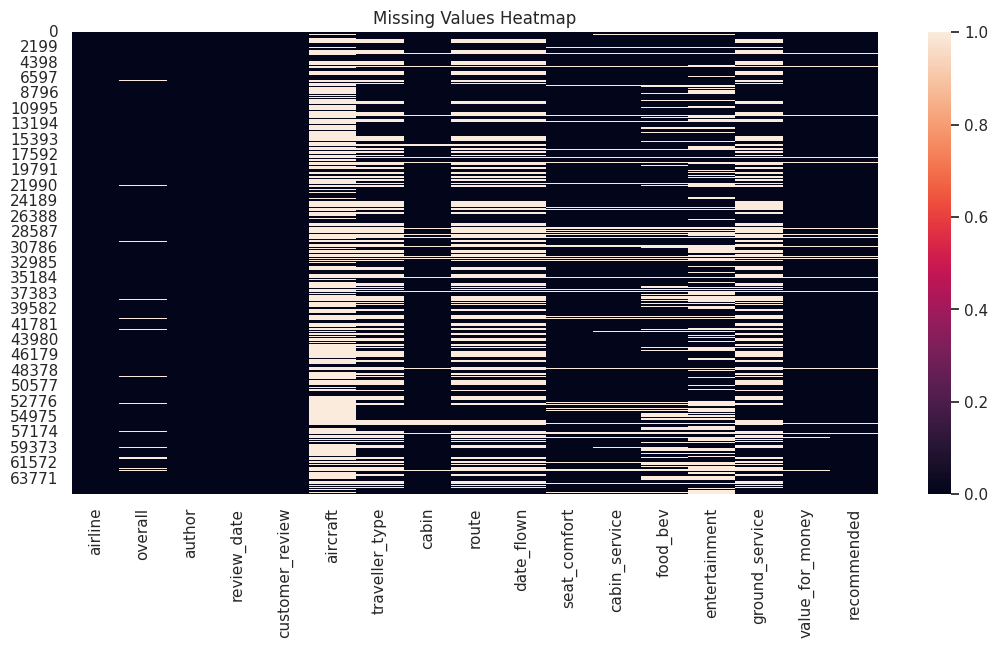

In [134]:
# Visualizing the missing values
plt.figure(figsize=(13,6))
sns.heatmap(df.isnull())
plt.title('Missing Values Heatmap')

What do you know about your dataset?
- Dataset Overview

The dataset used in this project contains airline reviews collected from 2006 to 2019 for major airlines operating worldwide. These reviews include both quantitative ratings and qualitative feedback from passengers, offering rich insights into customer satisfaction across various aspects of the flight experience.
The dataset comprises 131,895 rows and 17 features, each capturing a specific element of the travel and review experience and reflects a wide range of customer journeys, traveler types, and airline services.

- Data Quality Note

The dataset exhibits formatting inconsistencies in which alternate rows are empty, likely introduced during web scraping. As a result, preprocessing steps such as removing fully empty rows and handling missing values are necessary prior to model training.

# Understanding Your Variables

In [135]:
# columns in dataset
df_col = df.columns
df_col

Index(['airline', 'overall', 'author', 'review_date', 'customer_review',
       'aircraft', 'traveller_type', 'cabin', 'route', 'date_flown',
       'seat_comfort', 'cabin_service', 'food_bev', 'entertainment',
       'ground_service', 'value_for_money', 'recommended'],
      dtype='object')

In [136]:
df['airline'].unique()

array(['Turkish Airlines', 'Qatar Airways', 'Emirates', 'Lufthansa',
       'KLM Royal Dutch Airlines', 'Virgin America', 'American Airlines',
       'Delta Air Lines', 'Southwest Airlines', 'United Airlines',
       'Jetblue Airways', 'Aegean Airlines', 'Aeroflot Russian Airlines',
       'Aeromexico', 'Air Canada', 'Air New Zealand', 'Alitalia',
       'AirAsia', 'Asiana Airlines', 'Avianca', 'Austrian Airlines',
       'British Airways', 'Brussels Airlines', 'China Eastern Airlines',
       'China Southern Airlines', 'Copa Airlines', 'Ethiopian Airlines',
       'Egyptair', 'Finnair', 'Iberia', 'ANA All Nippon Airways',
       'easyJet', 'Korean Air', 'LATAM Airlines', 'LOT Polish Airlines',
       'Qantas Airways', 'Air France', 'Etihad Airways',
       'Pegasus Airlines', 'Royal Jordanian Airlines', 'Ryanair',
       'South African Airways', 'Saudi Arabian Airlines', 'TAP Portugal',
       'Eurowings', 'EVA Air', 'Royal Air Maroc', 'Singapore Airlines',
       'SAS Scandinavian', 

In [137]:
# description of dataset
df.describe()

,overall,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money
count,64017.000000,60681.000000,60715.000000,52608.000000,44193.000000,39358.000000,63975.000000
mean,5.145430,2.952160,3.191814,2.908170,2.863372,2.692820,2.943962
std,3.477532,1.441362,1.565789,1.481893,1.507262,1.612215,1.587370
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000
50%,5.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,9.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000
max,10.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [138]:
# Check Unique Values for each variable.
for i in df_col:
  print( "unique value in " , i ," :" , df[i].nunique())

unique value in  airline  : 81
unique value in  overall  : 10
unique value in  author  : 44069
unique value in  review_date  : 3015
unique value in  customer_review  : 61172
unique value in  aircraft  : 2088
unique value in  traveller_type  : 4
unique value in  cabin  : 4
unique value in  route  : 24549
unique value in  date_flown  : 63
unique value in  seat_comfort  : 5
unique value in  cabin_service  : 5
unique value in  food_bev  : 5
unique value in  entertainment  : 5
unique value in  ground_service  : 5
unique value in  value_for_money  : 5
unique value in  recommended  : 2


# Data Wrangling

In [139]:
# Making a copy of dataset for safety purpose
df1 = df.copy()

In [140]:
# Drop all duplicated rows as there are many blank and duplicated rows
df1.drop_duplicates(inplace = True)

In [141]:
# After dropping all duplicated rows we are reseting our index.
df1.reset_index(drop = True , inplace = True)

In [142]:
df1.duplicated().sum()

np.int64(0)

In [143]:
# after removing duplicates
df1.shape

(61183, 17)

Handling Null Values

In [144]:
print((df.isnull().sum() / len(df) * 100).sort_values(ascending = False))


aircraft           70.100232
ground_service     40.318741
date_flown         39.901739
route              39.760717
traveller_type     39.716742
entertainment      32.987096
food_bev           20.226849
seat_comfort        7.985200
cabin_service       7.933644
cabin               4.009280
value_for_money     2.990280
overall             2.926593
recommended         2.285168
airline             0.000000
review_date         0.000000
customer_review     0.000000
author              0.000000
dtype: float64


In [145]:
df1.drop(columns= 'aircraft', axis =1 , inplace = True)

The aircraft feature was excluded from the dataset as it had around 70% missing values, and imputing these values could have resulted in inaccurate data.

In [146]:
# droping unwanted columns
df1.drop(columns = ['author','customer_review','route'],axis = 1 , inplace = True)


In [147]:
df1.shape

(61183, 13)

In [148]:
print((df1.isnull().sum() / len(df1) * 100).sort_values(ascending = False))

ground_service     39.249465
date_flown         38.816338
traveller_type     38.643087
entertainment      34.246441
food_bev           20.989491
seat_comfort        8.126440
cabin_service       8.079042
cabin               4.050145
value_for_money     3.033522
overall             2.912574
recommended         2.324175
review_date         0.000000
airline             0.000000
dtype: float64


In [149]:
# drop null value from entertaintment & ground_service
df1.dropna(subset = (['ground_service','entertainment']),inplace = True)

In [150]:
# fill mising value in food_bev
df1['food_bev'].fillna(df1['food_bev'].mean(),inplace = True)

In [151]:
df1.dropna(inplace = True)

In [152]:
print((df1.isnull().sum() / len(df1) * 100).sort_values(ascending = False))

airline            0.0
overall            0.0
review_date        0.0
traveller_type     0.0
cabin              0.0
date_flown         0.0
seat_comfort       0.0
cabin_service      0.0
food_bev           0.0
entertainment      0.0
ground_service     0.0
value_for_money    0.0
recommended        0.0
dtype: float64


In [153]:
df1.shape

(23606, 13)

In [154]:
df1

,airline,overall,review_date,traveller_type,cabin,date_flown,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,Turkish Airlines,7.0,8th May 2019,Business,Economy Class,2019-05-01 00:00:00,4.0,5.0,4.0,4.0,2.0,4.0,yes
1,Turkish Airlines,2.0,7th May 2019,Family Leisure,Economy Class,2019-05-01 00:00:00,4.0,1.0,1.0,1.0,1.0,1.0,no
2,Turkish Airlines,3.0,7th May 2019,Business,Economy Class,2019-05-01 00:00:00,1.0,4.0,1.0,3.0,1.0,2.0,no
3,Turkish Airlines,10.0,6th May 2019,Solo Leisure,Economy Class,April 2019,4.0,5.0,5.0,5.0,5.0,5.0,yes
4,Turkish Airlines,1.0,6th May 2019,Solo Leisure,Economy Class,2019-05-01 00:00:00,1.0,1.0,1.0,1.0,1.0,1.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
61083,Ukraine International,1.0,6th August 2015,Family Leisure,Economy Class,July 2015,1.0,1.0,1.0,1.0,1.0,1.0,no
61084,Ukraine International,1.0,2nd August 2015,Family Leisure,Economy Class,July 2015,1.0,2.0,1.0,1.0,1.0,1.0,no
61086,Ukraine International,10.0,20th July 2015,Couple Leisure,Economy Class,July 2015,5.0,5.0,5.0,4.0,4.0,4.0,yes
61087,Ukraine International,2.0,18th July 2015,Solo Leisure,Economy Class,July 2015,1.0,1.0,1.0,1.0,1.0,1.0,no


Type Conversion

In [155]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23606 entries, 0 to 61091
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline          23606 non-null  object 
 1   overall          23606 non-null  float64
 2   review_date      23606 non-null  object 
 3   traveller_type   23606 non-null  object 
 4   cabin            23606 non-null  object 
 5   date_flown       23606 non-null  object 
 6   seat_comfort     23606 non-null  float64
 7   cabin_service    23606 non-null  float64
 8   food_bev         23606 non-null  float64
 9   entertainment    23606 non-null  float64
 10  ground_service   23606 non-null  float64
 11  value_for_money  23606 non-null  float64
 12  recommended      23606 non-null  object 
dtypes: float64(7), object(6)
memory usage: 3.0+ MB


In [156]:
# convert from object to integer
cols_to_convert = ['overall', 'seat_comfort', 'cabin_service','food_bev','entertainment','ground_service','value_for_money']

for col in cols_to_convert:
    df1[col] = df1[col].astype(np.int8)

In [157]:
# convert object to datetime
df1['date_flown'] = df1['date_flown'].astype('datetime64[ns]')
df1['review_date'] = df1['review_date'].astype('datetime64[ns]')

In [158]:
df1['review_date']

,review_date
0,2019-05-08
1,2019-05-07
2,2019-05-07
3,2019-05-06
4,2019-05-06
...,...
61083,2015-08-06
61084,2015-08-02
61086,2015-07-20
61087,2015-07-18


In [159]:
# renaming the column  name for better understanding
rename_col = {'overall' : 'overall_rating' , 'date_flown' : 'departure_date'}
df1.rename(columns= rename_col,inplace = True)

In [160]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23606 entries, 0 to 61091
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   airline          23606 non-null  object        
 1   overall_rating   23606 non-null  int8          
 2   review_date      23606 non-null  datetime64[ns]
 3   traveller_type   23606 non-null  object        
 4   cabin            23606 non-null  object        
 5   departure_date   23606 non-null  datetime64[ns]
 6   seat_comfort     23606 non-null  int8          
 7   cabin_service    23606 non-null  int8          
 8   food_bev         23606 non-null  int8          
 9   entertainment    23606 non-null  int8          
 10  ground_service   23606 non-null  int8          
 11  value_for_money  23606 non-null  int8          
 12  recommended      23606 non-null  object        
dtypes: datetime64[ns](2), int8(7), object(4)
memory usage: 1.9+ MB


In [161]:
df1.head()

,airline,overall_rating,review_date,traveller_type,cabin,departure_date,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,Turkish Airlines,7,2019-05-08,Business,Economy Class,2019-05-01,4,5,4,4,2,4,yes
1,Turkish Airlines,2,2019-05-07,Family Leisure,Economy Class,2019-05-01,4,1,1,1,1,1,no
2,Turkish Airlines,3,2019-05-07,Business,Economy Class,2019-05-01,1,4,1,3,1,2,no
3,Turkish Airlines,10,2019-05-06,Solo Leisure,Economy Class,2019-04-01,4,5,5,5,5,5,yes
4,Turkish Airlines,1,2019-05-06,Solo Leisure,Economy Class,2019-05-01,1,1,1,1,1,1,no


In [162]:
df1.to_csv('/content/airline_reviews.csv', index=False)

# After completing all data manipulations, meaningful insights were derived from the dataset.

* **Duplicates & Missing Values:** Duplicate records were removed, and missing values were handled appropriately. The aircraft column was dropped due to approximately 70% missing values, while author, customer_review, and route columns were removed as they were not relevant to the analysis. Missing values in food_bev were imputed using the mean.

* **Date Formatting:** The review_date and date_flown columns were converted from object type to a standardized date format. The time component in date_flown was removed to maintain consistency across date features.

* **Data Type Conversion:** Rating-related columns originally stored as floating-point values were converted to integers, as they represented discrete rating scores (e.g., 1.0, 2.0) and contained no additional information after decimal precision.

* **Column Renaming:** Columns were renamed to improve clarity and interpretability, such as renaming date_flown to departure_date and overall to overall_rating.

# Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables

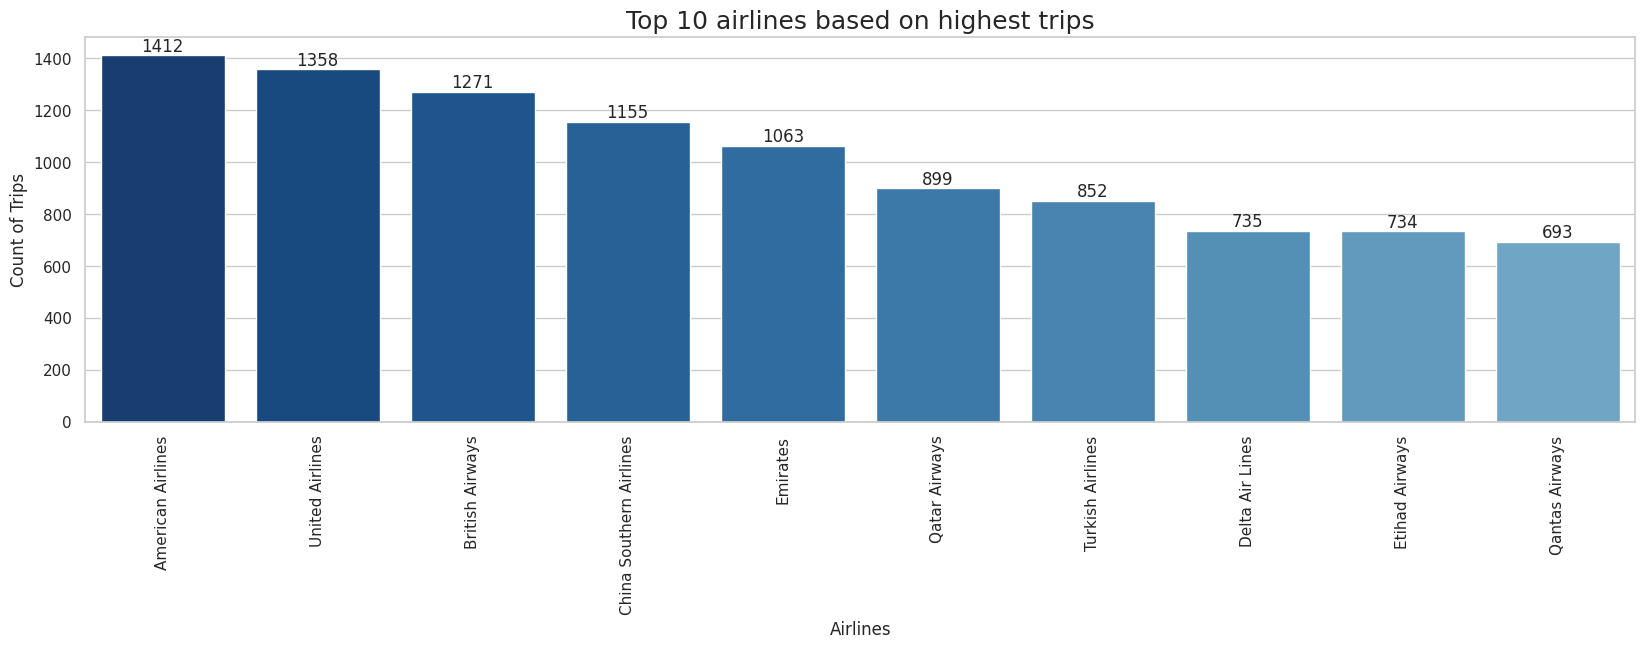

In [163]:
# Chart - 1 visualization code

air_cnt = df1['airline'].value_counts().sort_values(ascending=False).head(10).reset_index()
air_cnt.columns = ['airline_name', 'trip_count']

plt.figure(figsize = (20,5))
palette = sns.color_palette("Blues_r", 20)
ax = sns.barplot(x='airline_name', y='trip_count', data=air_cnt, palette=palette)
plt.xlabel('Airlines', fontsize=12)
plt.ylabel('Count of Trips', fontsize=12)
plt.xticks(rotation=90)
plt.title('Top 10 airlines based on highest trips', fontsize=18)

# Adding data labels on top of bars
for num in ax.containers:
    ax.bar_label(num)

plt.show()



1. Why this chart -

- Bar chart

  This chart was created to analyze airline dominance by trip volume, supporting data-driven insights into airline operations and customer reach.

2. Insights -
* American Airlines with **1412** and United Airlines with **1358** lead in trip count, indicating a strong operational network and higher market activity compared to other airlines.
* Middle Eastern carriers like Emirates, Qatar Airways, and Etihad Airways appear with comparatively fewer trips, reflecting a focus on long-haul international routes rather than high-frequency domestic travel.

3. Will the gained insights help creating a positive business impact?

   Yes, the gained insights can create a significant positive business impact
* Performed EDA to assess airline trip distribution
* Identified operational gaps by comparing trip frequency with customer ratings
* Generated actionable insights to support service optimization and business strategy


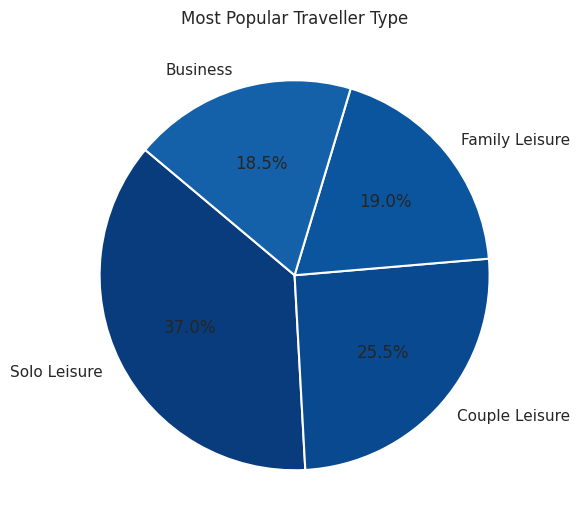

In [164]:
# chart 2

# Count values for traveller_type
traveller_counts = df1['traveller_type'].value_counts()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(traveller_counts,
        labels=traveller_counts.index,
        autopct='%1.1f%%',  # show percentage with 1 decimal
        startangle=140,      # start position of the first slice
        colors= palette,  # professional color palette
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})  # clean edges

# Title
plt.title('Most Popular Traveller Type')

# Show plot
plt.tight_layout()
plt.show()


1. Why this chart -
- Pie chart

  This chart was created to visualize the proportion of customers by traveller type, providing insights into travel preferences and supporting data-driven service and marketing strategies.

2. Insight -

   Analysis of traveller types indicates that Solo Leisure travellers make up the largest segment **(37%)**, followed by Couple Leisure **(25.5%)**, Family Leisure **(19%)**, and Business travellers **(18.5%)**. This highlights that the airline primarily serves leisure travellers.

3. Will the gained insights help creating a positive business impact?
   
   Yes, the gained insights can create a significant positive business impact.
   This analysis helps the airline identify which types of travelers contribute the most to overall traffic and revenue, along with their preferences, travel behavior, and service expectations. By understanding what different traveler segments value—such as solo travelers, business passengers, or leisure groups—the airline can design targeted offers, personalized services, and loyalty programs. These data-driven strategies help improve customer satisfaction, reduce churn, and strengthen long-term customer retention, ultimately driving sustainable growth and competitive advantage.


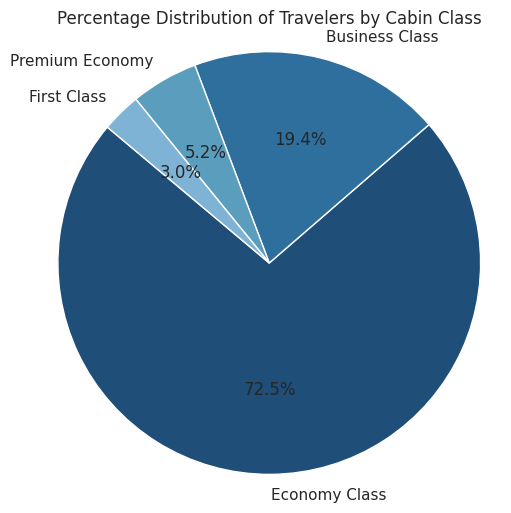

In [165]:
# chart 3

# Count travelers per cabin type
cabin_distribution = df1['cabin'].value_counts()

# Create pie chart
plt.figure(figsize=(6, 6))
plt.pie(cabin_distribution,
        labels=cabin_distribution.index,
        autopct='%1.1f%%', startangle=140 ,
        colors = ["#1F4E79","#2E6F9E", "#5B9DBD", "#7FB3D5"])

# Add title
plt.title('Percentage Distribution of Travelers by Cabin Class')

# Ensure pie is circular
plt.axis('equal')

# Display chart
plt.show()

1. Why this chart -
- Pie Chart

  This chart was created to visualize the proportion of customers across different cabin classes, helping identify the most preferred travel class and supporting data-driven decisions related to pricing, service differentiation, and targeted marketing strategies.

2. Insight -

   Economy Class accounts for the majority of travelers (72.5%), indicating high price sensitivity, while Business Class (19.4%) represents a strong premium segment. Premium Economy and First Class together form a small but high-value niche, suitable for targeted upgrade and revenue-enhancement strategies.

3. Will the gained insights help creating a positive business impact?

   Since Economy Class is the most preferred cabin, the airline can focus on competitive pricing and targeted offers for this segment to maximize customer retention. Additionally, identifying cabin classes with lower ratings helps prioritize service improvements, enhancing customer satisfaction, loyalty, and overall revenue growth


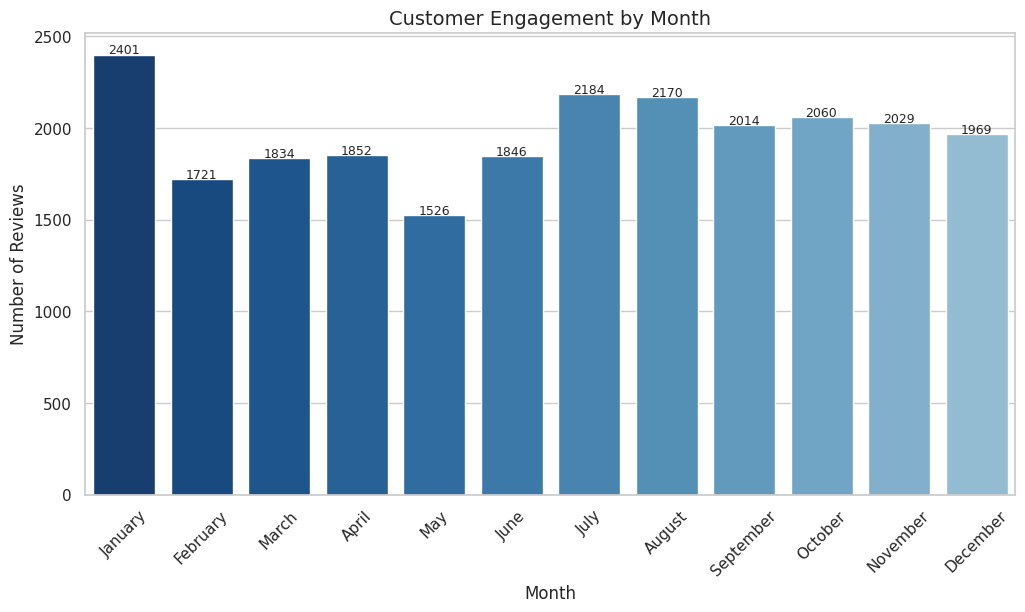

In [166]:
# chart - 4

# Extract month name from review_date
df1['month'] = df1['review_date'].dt.month_name()

# Define correct month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Count reviews per month (overall across all years)
monthly_reviews = df1['month'].value_counts().reindex(month_order)

# Plot bar chart
plt.figure(figsize=(12,6))
sns.barplot(x=monthly_reviews.index, y=monthly_reviews.values , palette= palette)

plt.title("Customer Engagement by Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)


# Add values on top of points (optional but looks professional)
for i, value in enumerate(monthly_reviews.values):
    plt.text(i, value + 5, str(value), ha='center', fontsize=9)

plt.show()


1. Why this chart -
* Bar chart - A bar chart was used to clearly compare the number of customer reviews across different months, helping identify peak engagement periods and seasonal trends in customer activity.

2. Insight -

   January has the highest review volume overall the number of reviews remains fairly stable throughout the year, mostly staying between ~1800 to 2200 reviews.

3. Will the gained insights help creating a positive business impact?
   
   Yes, these insights can create a strong positive business impact because they help the company understand monthly customer engagement patterns and take strategic actions accordingly.
   By analyzing review volume month-wise, the business can identify high-demand and low-demand periods, which supports better planning and decision-making.

   The business can use this data to plan offers and promotions more effectively

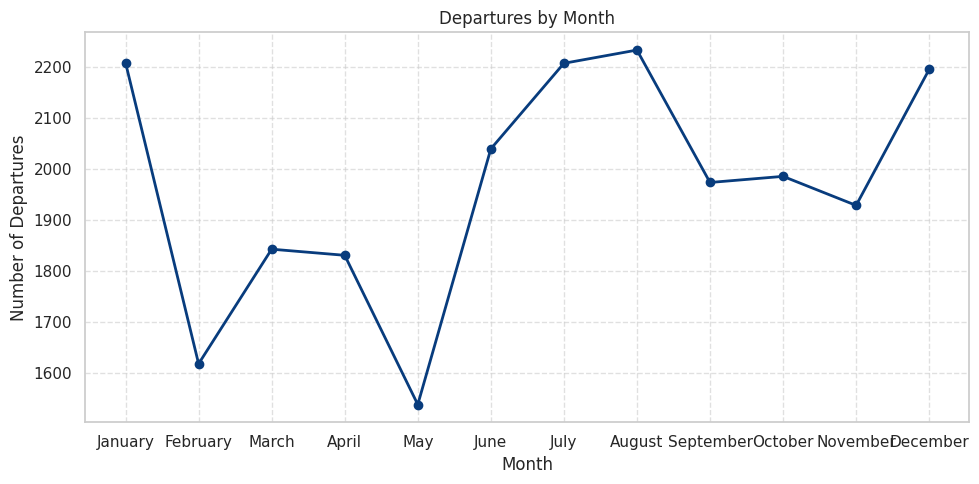

In [167]:
# chart - 5

# Ensure departure_date is datetime
df1['departure_date'] = pd.to_datetime(df1['departure_date'])

# Count departures per month (without adding new columns)
monthly_departures = (df1['departure_date'].dt.month.value_counts().reindex(range(1, 13), fill_value=0))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(month_order, monthly_departures.values, marker='o', linewidth=2)

plt.title("Departures by Month")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Departures", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


1. Why this chart -

* Line Chart – A line chart is the best choice because it clearly represents departure trends over time (month-wise). It helps identify seasonal patterns, peak travel months, and low-demand months by showing continuous rise and fall in departures across the year.

2. Insight -
* August has the highest departures, showing peak travel demand.
* May has the lowest departures, indicating reduced travel activity.
* Departures rise sharply from June to August, reflecting seasonal growth.
* Departures remain stable from September to November and increase again in December.

3. Will the gained insights help creating a positive business impact?

   Yes, these insights help airlines understand peak and low-demand months. This supports better staff planning, flight scheduling, and promotional strategy, improving operational efficiency and customer satisfaction.



In [168]:
df1.drop(columns= 'month',inplace = True)

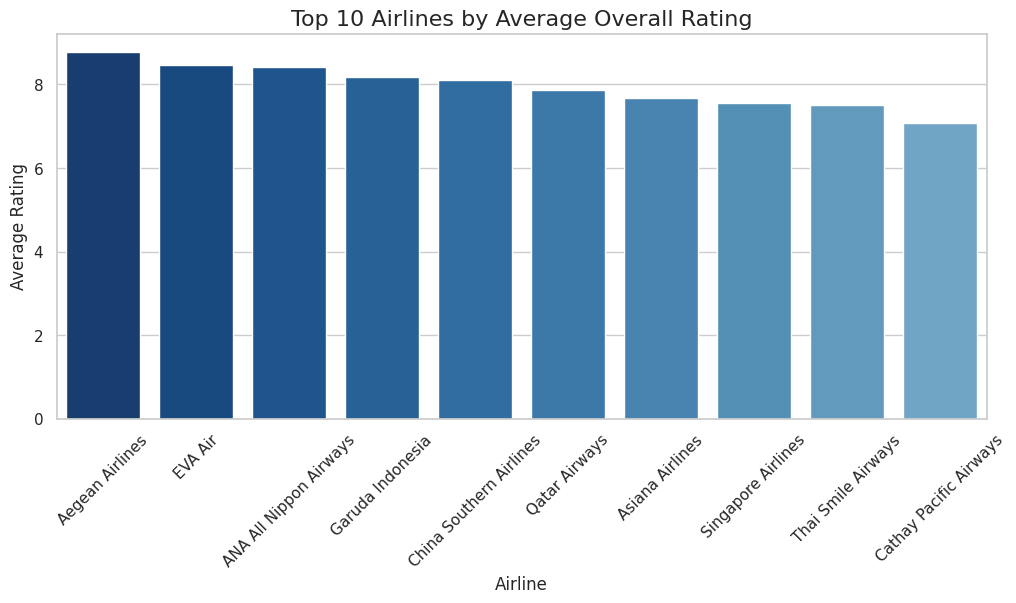

In [169]:
#chart - 6

# Average rating per airline
airline_rating = (
    df1.groupby("airline")["overall_rating"].mean().sort_values(ascending=False).reset_index()
)

airline_rating.rename(columns={"overall_rating": "avg_overall_rating"}, inplace=True)

top10_airlines = airline_rating.head(10)

plt.figure(figsize=(12,5))

# Create bar chart
sns.barplot(
    data=top10_airlines,
    x="airline",
    y="avg_overall_rating",
    palette= palette
)

plt.title("Top 10 Airlines by Average Overall Rating", fontsize=16)
plt.xlabel("Airline", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.xticks(rotation=45)
plt.show()


1. Why this chart -
* Bar chart - The bar chart helps visualize airline-wise rating differences, enabling quick comparison of customer satisfaction levels across multiple airlines.

2. Insights -
* Aegean Airlines and EVA Air have the highest average customer ratings, showing strong service quality.
* High-rated airlines are not always the most frequent operators, proving that service quality and trip volume are not directly related.
* Airlines like Qatar Airways and Singapore Airlines maintain consistently strong customer satisfaction.

3. Will the gained insights help creating a positive business impact?

   By analyzing both trip frequency and overall customer ratings, we can identify that airlines with the highest number of trips do not always achieve the highest customer satisfaction. This helps highlight performance gaps where service quality may need improvement despite high operational activity. Such insights support airlines in improving customer experience, strengthening brand reputation, optimizing service operations, and making data-driven strategic decisions to stay competitive.


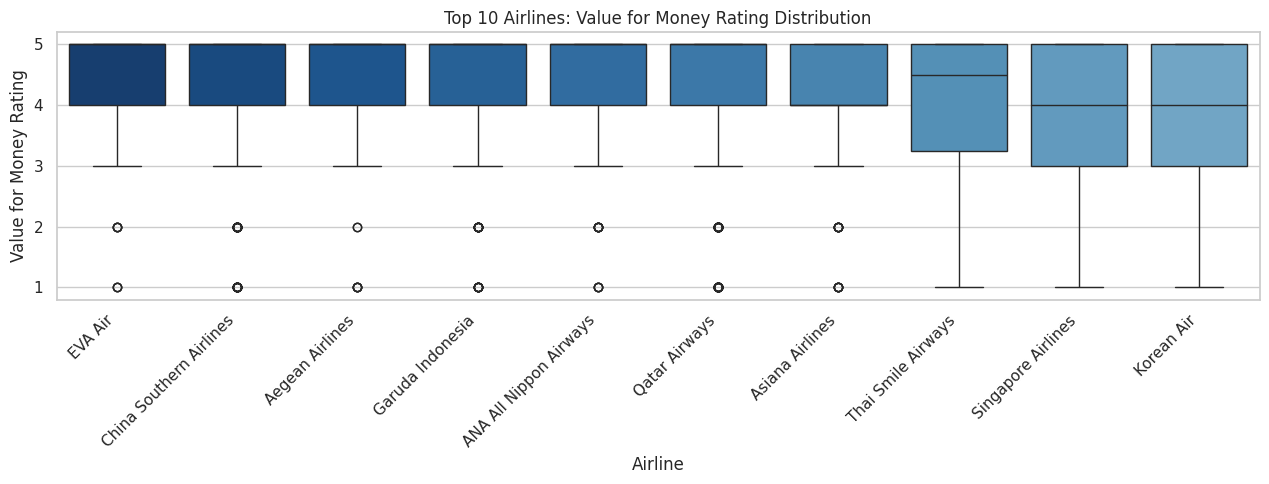

In [170]:
# chart - 7

top10_airlines = (df1.groupby('airline')['value_for_money'].mean().sort_values(ascending=False).head(10).index)

# Filter dataset for only top 10 airlines
df_top10 = df1[df1['airline'].isin(top10_airlines)]

# Set plot style
sns.set(style="whitegrid")

# Plot boxplot
plt.figure(figsize=(13, 5))
sns.boxplot(data=df_top10, x='airline', y='value_for_money', order=top10_airlines, palette= palette)

plt.title("Top 10 Airlines: Value for Money Rating Distribution")
plt.xlabel("Airline", fontsize=12)
plt.ylabel("Value for Money Rating", fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



1. Why this chart -

   Box Plot – This chart is used because it shows the distribution of value-for-money ratings for each airline, including median, variation, and outliers. It helps compare customer satisfaction across the top 10 airlines more effectively than just using averages.

2. Insights -

* Most airlines have ratings concentrated between 4 and 5, indicating strong value-for-money perception.

* Airlines like EVA Air show more consistent ratings, reflecting stable customer satisfaction.

* Some airlines display outliers (1 or 2 ratings), suggesting occasional negative customer experiences despite overall high ratings.

3. Will the gained insights help creating a positive business impact?

   Yes, these insights help airlines understand customer satisfaction consistency. They support improvements in service quality and pricing strategies, strengthen brand reputation, and enable data-driven decisions to remain competitive.

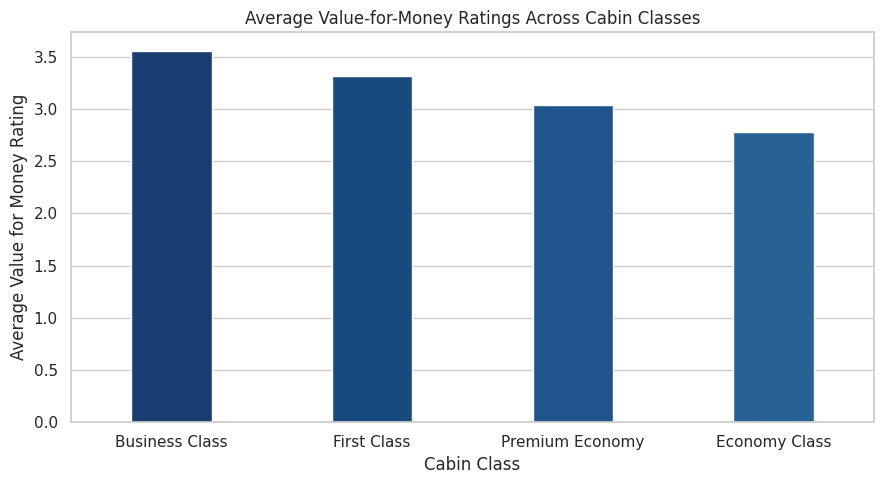

In [171]:
#chart -8

# Calculate average value for money rating per cabin
cabin_avg = (df1.groupby('cabin')['value_for_money'].mean().sort_values(ascending=False))

# Plot bar chart
plt.figure(figsize=(9, 5))
sns.barplot(x=cabin_avg.index, y=cabin_avg.values,width=0.4,palette= palette)

plt.title('Average Value-for-Money Ratings Across Cabin Classes')
plt.xlabel("Cabin Class", fontsize=12)
plt.ylabel("Average Value for Money Rating", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

1. Why this chart -

   Bar Chart – This chart is chosen because it clearly compares the average value-for-money rating across different cabin classes. It provides an easy visual comparison to identify which cabin category offers the best perceived value based on customer feedback.

2. Insights -
* Business Class has the highest value-for-money rating, showing the strongest customer satisfaction.
* First Class also performs well but is slightly lower, possibly due to higher price expectations.
* Premium Economy shows moderate ratings, indicating balanced comfort and cost.
* Economy Class has the lowest rating, suggesting customers may feel the value is comparatively lower.

3. Will the gained insights help creating a positive business impact?

   Yes, this insight can help airlines because it clearly shows which cabin customers feel is worth the money. Airlines can use this information to improve the Economy class experience, adjust pricing, and focus on better service where ratings are low. This can increase customer satisfaction and help the airline attract more passengers.

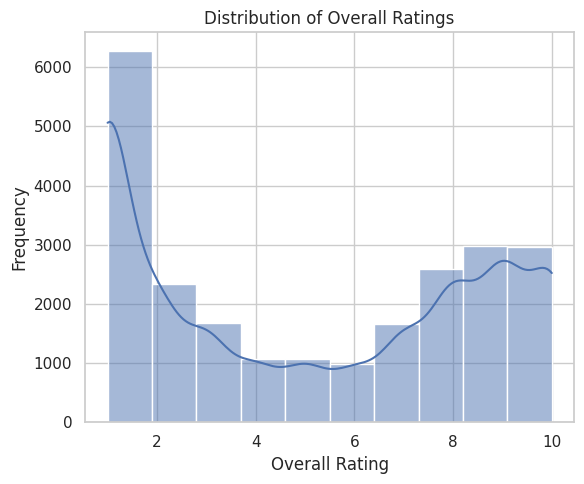

In [172]:
# chart - 9

# Plot distribution
plt.figure(figsize=(6, 5))
sns.histplot(df1['overall_rating'], bins=10, kde=True)

# Title and labels
plt.title("Distribution of Overall Ratings")
plt.xlabel("Overall Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.show()

1. Why this chart -

   Histogram with KDE curve -  is chosen because it clearly shows the distribution of overall ratings, helping identify the most common rating ranges and overall customer satisfaction trend.

2. Insights -
   We can conclude that most people gave ratings between either 1–2 or 8–10. This suggests that passengers tend to have either a very good or a very bad experience with the airline, with fewer neutral opinions in between.

3. Will the gained insights help creating a positive business impact?
   
   Yes, this insight helps businesses understand customer satisfaction levels and identify service gaps. It supports improving weak areas that cause low ratings while strengthening factors that lead to high satisfaction, ultimately improving customer retention and brand reputation.

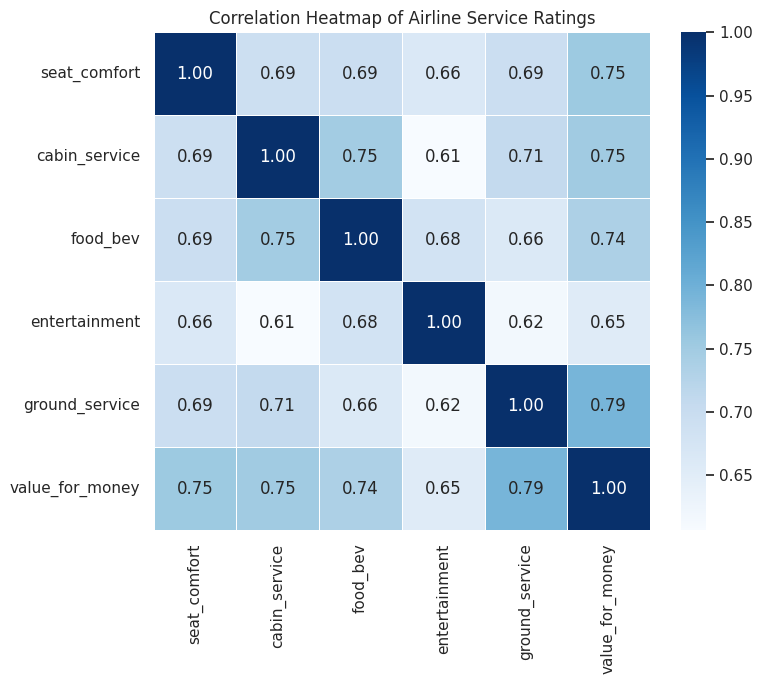

In [173]:
# chart - 10

# Select only rating columns (numerical)
rating_cols = [
    'seat_comfort', 'cabin_service',
    'food_bev', 'entertainment', 'ground_service',
    'value_for_money'
]

# Create correlation matrix
corr_matrix = df[rating_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap of Airline Service Ratings")
plt.tight_layout()
plt.show()

1. Why this chart -

   Heatmap (Correlation Matrix) - is chosen because it clearly shows the relationship between different service rating factors. It helps identify which factors move together and which service areas most influence customer satisfaction.

2. Insights -
* All service factors show a strong positive correlation, meaning better service in one area usually improves other ratings as well.
* Value for money has the strongest correlation with ground service (0.79), indicating ground experience heavily affects customer perception of pricing value.
* Cabin service and food & beverage (0.75) are strongly linked, showing onboard service quality impacts food satisfaction.
* Entertainment has comparatively lower correlations, suggesting it is less influential than other service factors.

3. Will the gained insights help creating a positive business impact?

   Yes, these insights help airlines prioritize improvements in the most impactful service areas like ground service, cabin service, and seat comfort, which can increase customer satisfaction, improve ratings, and strengthen brand reputation.



<Axes: title={'center': 'Overall rating vs cabin type'}, xlabel='cabin', ylabel='overall_rating'>

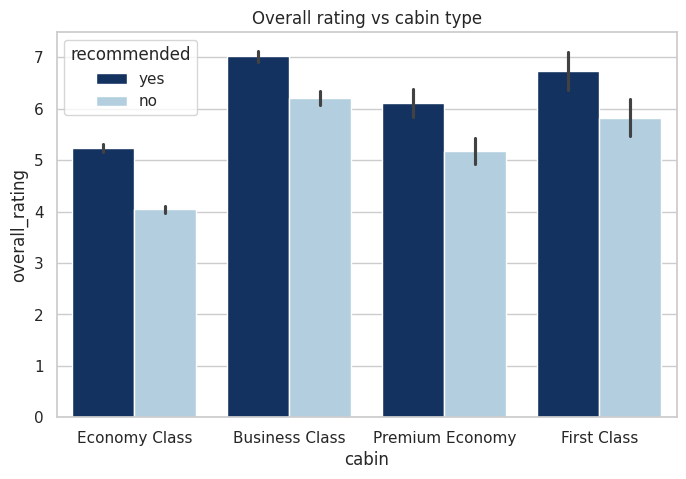

In [174]:
# Chart - 11
plt.figure(figsize=(8,5))
plt.title('Overall rating vs cabin type')
sns.barplot(x = df1.cabin, y = df1.overall_rating, hue = df['recommended'], palette= ['#08306B','#ACD1E6'])

1. Why I used this chart
   
   This grouped bar chart is used to compare overall ratings across different cabin types while also showing how ratings differ between recommended (yes) and not recommended (no) customers. It helps understand how cabin experience influences customer satisfaction.

2. Insights
* Business Class and First Class have the highest overall ratings, especially for recommended customers.
* Economy Class has the lowest ratings, particularly among non-recommended customers.
* In every cabin type, customers who recommended the airline gave significantly higher ratings than those who did not.

3. Will the gained insights help creating a positive business impact?

   Yes, these insights can help airlines improve performance by identifying which cabin classes need service improvement (especially Economy), enhancing customer experience, and increasing recommendation rates.

<Figure size 1000x700 with 0 Axes>

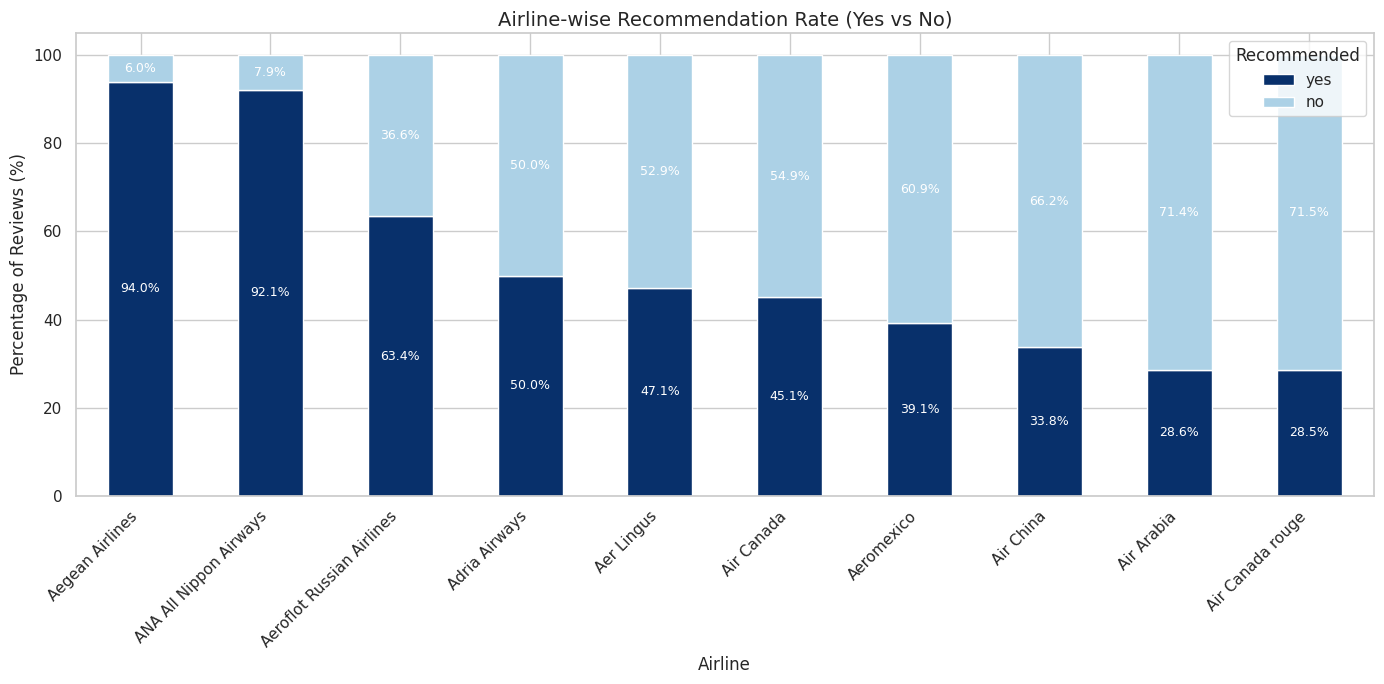

In [175]:
# chart - 12

# Create a summary table: count of Yes/No recommendations for each airline
airline_recommend_counts = (df1.groupby(['airline', 'recommended']).size().unstack(fill_value=0).head(10))

# Calculate percentage of recommendations (Yes %)
airline_recommend_percent = airline_recommend_counts.div(
    airline_recommend_counts.sum(axis=1), axis=0
) * 100

# Sort airlines by highest "Yes" recommendation percentage
airline_recommend_percent = airline_recommend_percent.sort_values(by='yes', ascending=False)

# Plot stacked bar chart (percentage-based)
plt.figure(figsize=(10, 7))

airline_recommend_percent[['yes', 'no']].plot(kind='bar',stacked=True,figsize=(14, 7),color=['#08306B', '#ACD1E6'] )

plt.title("Airline-wise Recommendation Rate (Yes vs No)", fontsize=14)
plt.xlabel("Airline", fontsize=12)
plt.ylabel("Percentage of Reviews (%)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Recommended", loc="upper right")

# Add percentage labels inside bars for better readability
for index, (yes_val, no_val) in enumerate(zip(airline_recommend_percent['yes'], airline_recommend_percent['no'])):
    plt.text(index, yes_val / 2, f"{yes_val:.1f}%", ha='center', va='center', fontsize=9, color='white')
    plt.text(index, yes_val + (no_val / 2), f"{no_val:.1f}%", ha='center', va='center', fontsize=9, color='white')

plt.tight_layout()
plt.show()


1. Why this chart -
* Stacked bar
  
  This stacked bar chart is used to compare the percentage of recommended (Yes) vs not recommended (No) reviews for each airline. It clearly shows customer satisfaction levels and makes airline-wise comparison easy.

2. Insights
* Aegean Airlines (94%) and Nippon Airways (92.1%) have the highest recommendation rates, indicating strong customer satisfaction.
* Airlines like Air Arabia (28.6%) and Canada Rouge (28.5%) have the lowest recommendation rates, showing high dissatisfaction.
* Some airlines have a nearly equal split, suggesting inconsistent service quality.

3. Will the gained insights help creating a positive business impact?

   Yes, these insights can help improve business performance by identifying airlines with low recommendation rates. This helps highlight service gaps, improve customer experience, enhance customer service quality, and ultimately increase customer loyalty.

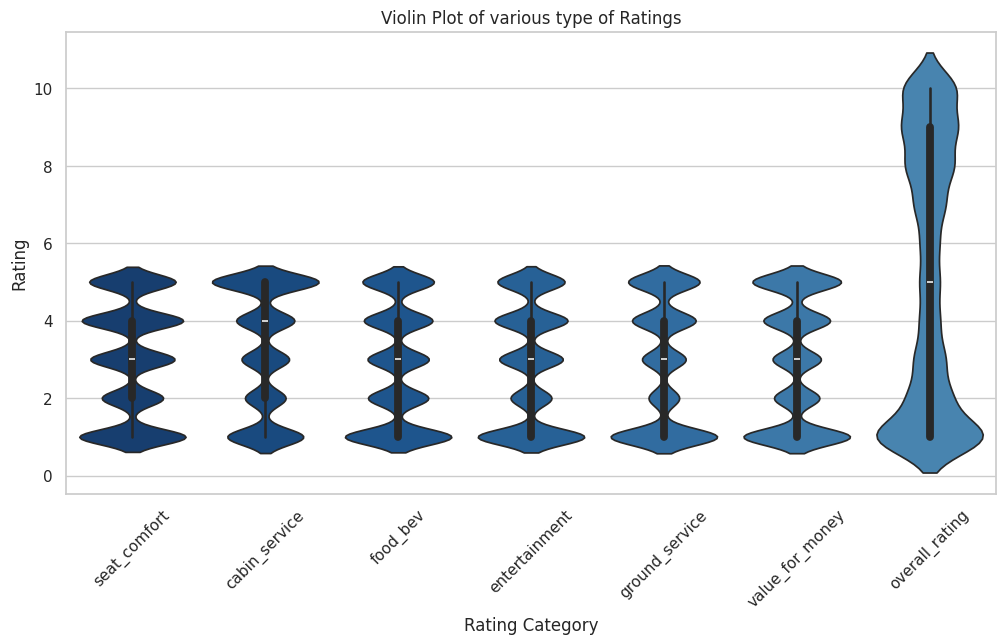

In [176]:
# Chart - 13

columns = ['seat_comfort', 'cabin_service', 'food_bev', 'entertainment', 'ground_service', 'value_for_money','overall_rating']

df_melted = df1.melt(value_vars=columns, var_name='Rating Category', value_name='Rating')

# violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='Rating Category', y='Rating', data=df_melted,palette= palette)
plt.title('Violin Plot of various type of Ratings')
plt.xticks(rotation=45)
plt.show()

1. Why this chart -
* Voilin chart

   This violin plot is used to visualize the distribution and density of different rating categories, showing where most customer ratings are concentrated.

2. Insight -

   Most service ratings are clustered between 2 and 4, while overall_rating shows a wider spread, indicating mixed customer satisfaction levels.
3. Will the gained insights help creating a positive business impact?

   Yes, these insights help identify weak service areas, improve customer experience, and increase overall satisfaction and recommendation rates.

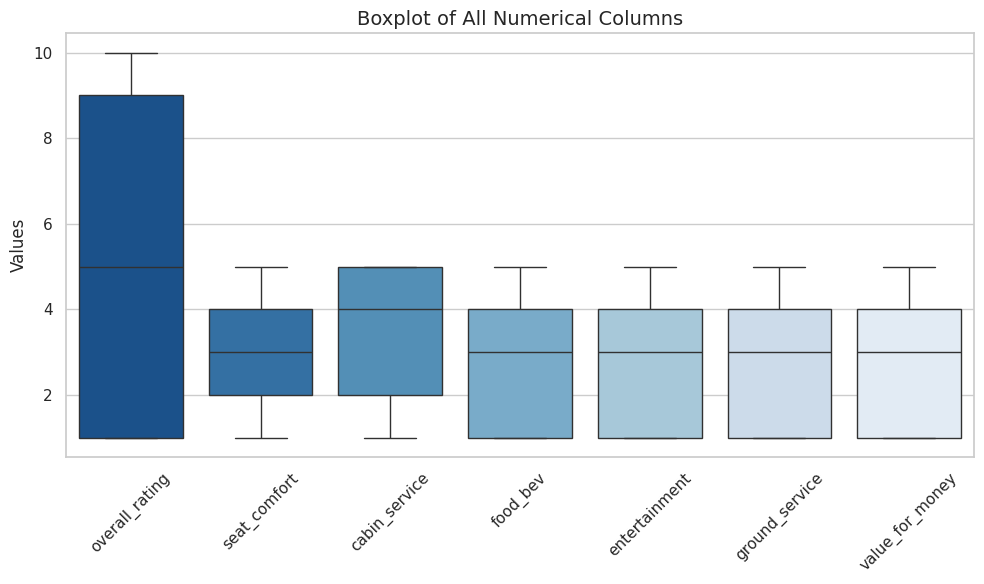

In [177]:
# chart - 14

# Select only numerical columns
num_cols = df1.select_dtypes(include=['int8']).columns

# Create boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df1[num_cols], palette="Blues_r")

plt.title("Boxplot of All Numerical Columns", fontsize=14)
plt.xticks(rotation=45)
plt.ylabel("Values")

plt.tight_layout()
plt.show()

1. Why this chart -
* Box Plot
  
  This boxplot is used to understand the distribution, spread, and outliers in all numerical rating columns. It helps identify which service areas have more variation in customer feedback
2. Insight -
   
   The chart shows that overall_rating has the highest variation, meaning customer experiences differ widely, while most service ratings are around the average range (2–4). Additionally, no major outliers are observed, indicating the data is consistent and not influenced by extreme values.

3. Will the gained insights help creating a positive business impact?

   Yes, these insights help businesses detect inconsistent service areas, reduce negative experiences, and improve customer satisfaction, leading to better recommendations and retention.

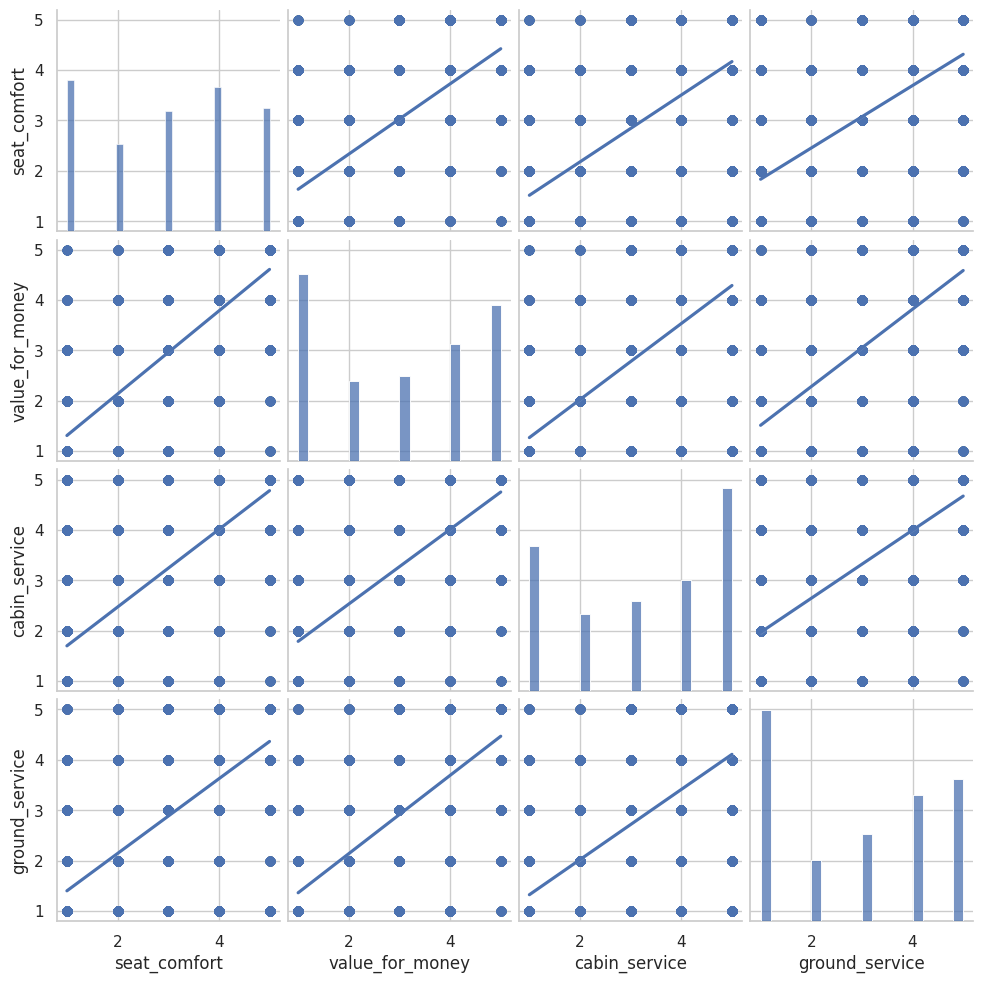

In [178]:
# Chart - 15
column_name = [ 'seat_comfort','value_for_money','cabin_service','ground_service']
sns.pairplot(df1[column_name],kind = 'reg')
plt.show()


1. why this chart -
   
   Here we wanted to have a pairwise visualisation of all the columns in the dataset , hence used pairplot.
2. Insight -

   Since our dataset contains discrete values, the distribution isn’t perfectly smooth. However, we can still observe a positive relationship between all the rating-related columns.

In [179]:
df1

,airline,overall_rating,review_date,traveller_type,cabin,departure_date,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,Turkish Airlines,7,2019-05-08,Business,Economy Class,2019-05-01,4,5,4,4,2,4,yes
1,Turkish Airlines,2,2019-05-07,Family Leisure,Economy Class,2019-05-01,4,1,1,1,1,1,no
2,Turkish Airlines,3,2019-05-07,Business,Economy Class,2019-05-01,1,4,1,3,1,2,no
3,Turkish Airlines,10,2019-05-06,Solo Leisure,Economy Class,2019-04-01,4,5,5,5,5,5,yes
4,Turkish Airlines,1,2019-05-06,Solo Leisure,Economy Class,2019-05-01,1,1,1,1,1,1,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
61083,Ukraine International,1,2015-08-06,Family Leisure,Economy Class,2015-07-01,1,1,1,1,1,1,no
61084,Ukraine International,1,2015-08-02,Family Leisure,Economy Class,2015-07-01,1,2,1,1,1,1,no
61086,Ukraine International,10,2015-07-20,Couple Leisure,Economy Class,2015-07-01,5,5,5,4,4,4,yes
61087,Ukraine International,2,2015-07-18,Solo Leisure,Economy Class,2015-07-01,1,1,1,1,1,1,no


#  Hypothesis Testing

# Hypothetical Statement - 1

Does Overall Rating Influence Airline Recommendation?

1. State your research hypothesis as a Null Hypothesis and Alternate Hypothesis

* Null Hypothesis (H0):
There is no significant difference in overall ratings between customers who recommend the airline and those who do not recommend it.
* Alternative Hypothesis (H1):
There is a significant difference in overall ratings between customers who recommend the airline and those who do not recommend it.

In [180]:
# Split the data into two groups based on recommendation
yes_ratings = df1[df1['recommended'] == 'yes']['overall_rating']
no_ratings  = df1[df1['recommended'] == 'no']['overall_rating']

# Perform Independent T-Test
t_stat, p_value = ttest_ind(yes_ratings, no_ratings, equal_var=False)

# Display results
print(f"Mean Overall Rating (Recommended = Yes): {yes_ratings.mean():.2f}")
print(f"Mean Overall Rating (Recommended = No) : {no_ratings.mean():.2f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value    : {p_value:.6f}")

# Significance level
alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis (H0)")
    print("Conclusion: Customers who recommend the airline give significantly higher overall ratings.")
else:
    print("Result: Fail to Reject the Null Hypothesis (H0)")
    print("Conclusion: No significant difference found between the two groups.")

Mean Overall Rating (Recommended = Yes): 8.35
Mean Overall Rating (Recommended = No) : 2.12
T-Statistic: 316.9302
P-Value    : 0.000000
Result: Reject the Null Hypothesis (H0)
Conclusion: Customers who recommend the airline give significantly higher overall ratings.


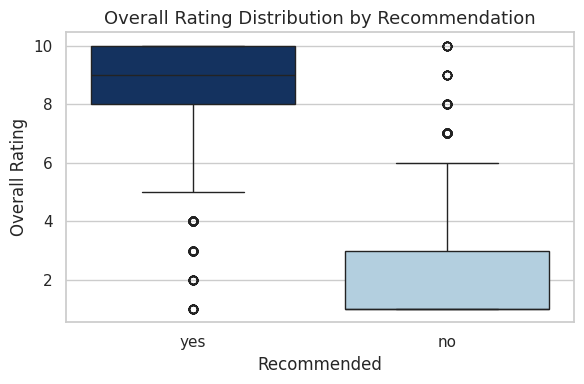

In [181]:
# Visualization
plt.figure(figsize=(6,4))
sns.boxplot(x='recommended', y='overall_rating', data=df1, palette=['#08306B','#ACD1E6'])

plt.title("Overall Rating Distribution by Recommendation", fontsize=13)
plt.xlabel("Recommended")
plt.ylabel("Overall Rating")

plt.tight_layout()
plt.show()

I used an Independent T-Test because the goal is to check whether the mean overall_rating differs significantly between two independent groups: customers who recommended (Yes) and those who did not recommend (No) the airline.

This test is appropriate since:
* the dependent variable (overall_rating) is numerical,
* the independent variable (recommended) has only two categories,
and it helps compute the p-value to determine whether the observed difference is statistically significant.

# Hypothetical Statement - 2
Does Cabin Type Impact Overall Rating?
State your research hypothesis as a Null Hypothesis and Alternate Hypothesis

* Null Hypothesis (H0):
There is no significant difference in overall ratings across different cabin types.
* Alternative Hypothesis (H1):
There is a significant difference in overall ratings across different cabin types.

In [182]:
# Create a contingency table (frequency table)
contingency_table = pd.crosstab(df1['cabin'], df1['recommended'])

# Perform Chi-Square Test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Print Chi-Square results
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"Degrees of Freedom  : {dof}")
print(f"P-Value             : {p_value:.6f}")

# Significance level
alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis (H0)")
    print("Conclusion: Cabin type significantly influences recommendation.")
else:
    print("Result: Fail to Reject the Null Hypothesis (H0)")
    print("Conclusion: Cabin type does not significantly influence recommendation.")


Chi-Square Statistic: 1062.2317
Degrees of Freedom  : 3
P-Value             : 0.000000
Result: Reject the Null Hypothesis (H0)
Conclusion: Cabin type significantly influences recommendation.


I used the Chi-Square Test of Independence because both cabin type and recommendation (yes/no) are categorical variables. This test helps determine whether there is a statistically significant relationship between cabin type and customer recommendation by calculating the p-value.

# Hypothetical Statement - 3
Hypothesis: Traveller Type Affects Satisfaction

Research Question
- Do business travellers give lower (stricter) ratings than leisure travellers?

* Null Hypothesis (H0):
There is no significant difference in overall ratings between different traveller types.

* Alternative Hypothesis (H1):
There is a significant difference in overall ratings between different traveller types (business travellers rate more strictly than leisure travellers).

In [183]:
# Group overall ratings based on traveller type
groups = [
    group["overall_rating"].values
    for name, group in df1.groupby("traveller_type")
]

# Perform One-Way ANOVA test
f_stat, p_value = f_oneway(*groups)

# Display results
print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value     : {p_value:.6f}")

# Decision based on significance level
alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis (H0)")
    print("Conclusion: Traveller type significantly affects overall ratings.")
else:
    print("\nResult: Fail to Reject the Null Hypothesis (H0)")
    print("Conclusion: Traveller type does not significantly affect overall ratings.")

F-Statistic : 95.8725
P-Value     : 0.000000

Result: Reject the Null Hypothesis (H0)
Conclusion: Traveller type significantly affects overall ratings.


I use One-Way ANOVA because traveller_type has more than two categories and want to check whether the mean overall_rating differs significantly across these multiple groups.

# Feature Engineering & Data Pre-processing

In [184]:
# Handling null values
df1.isnull().sum()

,0
airline,0
overall_rating,0
review_date,0
traveller_type,0
cabin,0
departure_date,0
seat_comfort,0
cabin_service,0
food_bev,0
entertainment,0


There are no null values since they have already been handled.

 2. Categorical Encoding

In [185]:
# Encode your categorical columns
le = LabelEncoder()
df1['recommended'] = le.fit_transform(df1['recommended'])

used Label Encoding to convert the categorical recommended column (Yes/No) into numerical values (0 and 1) for easier analysis and model processing.

In [186]:
one_hot_encoder = ce.OneHotEncoder(cols=['traveller_type'])
df1 = one_hot_encoder.fit_transform(df1)


In [187]:
ordinal_encoder = ce.OrdinalEncoder(mapping=[{'col': 'cabin', 'mapping': {'Economy Class': 1, 'Premium Economy' : 2,'Business Class': 3,'First Class' :4}}])
df1['cabin']= ordinal_encoder.fit_transform(df['cabin'])
df1['cabin'] = df1['cabin'].astype('int8')

In [188]:
df1

,airline,overall_rating,review_date,traveller_type_1,traveller_type_2,traveller_type_3,traveller_type_4,cabin,departure_date,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,Turkish Airlines,7,2019-05-08,1,0,0,0,1,2019-05-01,4,5,4,4,2,4,1
1,Turkish Airlines,2,2019-05-07,0,1,0,0,1,2019-05-01,4,1,1,1,1,1,0
2,Turkish Airlines,3,2019-05-07,1,0,0,0,1,2019-05-01,1,4,1,3,1,2,0
3,Turkish Airlines,10,2019-05-06,0,0,1,0,1,2019-04-01,4,5,5,5,5,5,1
4,Turkish Airlines,1,2019-05-06,0,0,1,0,1,2019-05-01,1,1,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61083,Ukraine International,1,2015-08-06,0,1,0,0,3,2015-07-01,1,1,1,1,1,1,0
61084,Ukraine International,1,2015-08-02,0,1,0,0,1,2015-07-01,1,2,1,1,1,1,0
61086,Ukraine International,10,2015-07-20,0,0,0,1,1,2015-07-01,5,5,5,4,4,4,1
61087,Ukraine International,2,2015-07-18,0,0,1,0,1,2015-07-01,1,1,1,1,1,1,0


Categorical Encoding Techniques Used

Since machine learning models require numerical input, categorical columns were converted into numbers using suitable encoding methods:
* Traveller_Type: Used one-hot encoding because it has multiple categories with no specific order.
* Cabin: Used ordinal encoding because cabin classes follow a clear hierarchy (Economy < Premium Economy < Business < First).
* Recommended: Used label encoding because it is a binary column (Yes/No).

3. Feature Manipulation & Selection

In [189]:
df1.drop(columns = ['airline', 'review_date','departure_date'] ,inplace = True)

I dropped the airline, review_date, and departure_date columns because they were not required for the current analysis/modeling and removing them helps reduce unnecessary complexity in the dataset.

In [190]:
X = df1.drop('recommended', axis=1)
y = df1['recommended']

selector = SelectKBest(score_func=f_classif, k='all')
X_new = selector.fit_transform(X, y)

feature_scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
print(feature_scores.sort_values(by='Score', ascending=False).reset_index(drop=True))


             Feature          Score
0     overall_rating  100535.140280
1    value_for_money   56434.657575
2     ground_service   31399.451221
3      cabin_service   29048.840941
4           food_bev   26823.110361
5       seat_comfort   26235.751841
6      entertainment   17103.198582
7   traveller_type_3     296.852367
8   traveller_type_4     112.061408
9              cabin      34.924653
10  traveller_type_2      30.753898
11  traveller_type_1      14.712038


In [191]:
corr_matrix = df1[['overall_rating','cabin_service','seat_comfort','food_bev','entertainment','ground_service','value_for_money','recommended']].corr()
corr_matrix

,overall_rating,cabin_service,seat_comfort,food_bev,entertainment,ground_service,value_for_money,recommended
overall_rating,1.000000,0.802345,0.795892,0.793299,0.720355,0.826567,0.899440,0.899921
cabin_service,0.802345,1.000000,0.715203,0.759962,0.643760,0.686711,0.748290,0.742769
seat_comfort,0.795892,0.715203,1.000000,0.720664,0.698042,0.678297,0.758516,0.725536
food_bev,0.793299,0.759962,0.720664,1.000000,0.704976,0.655019,0.747458,0.729327
entertainment,0.720355,0.643760,0.698042,0.704976,1.000000,0.615235,0.679103,0.648191
ground_service,0.826567,0.686711,0.678297,0.655019,0.615235,1.000000,0.772872,0.755555
value_for_money,0.899440,0.748290,0.758516,0.747458,0.679103,0.772872,1.000000,0.839698
recommended,0.899921,0.742769,0.725536,0.729327,0.648191,0.755555,0.839698,1.000000


In [192]:
# Dropping the overall ratings because of data leakage
df1.drop('overall_rating',axis= 1 , inplace = True)

In [193]:
df1.head()

,traveller_type_1,traveller_type_2,traveller_type_3,traveller_type_4,cabin,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,1,0,0,0,1,4,5,4,4,2,4,1
1,0,1,0,0,1,4,1,1,1,1,1,0
2,1,0,0,0,1,1,4,1,3,1,2,0
3,0,0,1,0,1,4,5,5,5,5,5,1
4,0,0,1,0,1,1,1,1,1,1,1,0


In [194]:
selected_col = df1[['cabin_service','seat_comfort','food_bev','entertainment','ground_service','value_for_money']]
selected_col

,cabin_service,seat_comfort,food_bev,entertainment,ground_service,value_for_money
0,5,4,4,4,2,4
1,1,4,1,1,1,1
2,4,1,1,3,1,2
3,5,4,5,5,5,5
4,1,1,1,1,1,1
...,...,...,...,...,...,...
61083,1,1,1,1,1,1
61084,2,1,1,1,1,1
61086,5,5,5,4,4,4
61087,1,1,1,1,1,1


4. Data Splitting

In [195]:
x = selected_col
y = df1['recommended']

In [196]:
x_train, x_test , y_train , y_test = train_test_split(x,y,test_size= 0.30,random_state= 42)

In [197]:
print("x_train size :",x_train.shape)
print("x_test size :",x_test.shape)
print("y_train size :",y_train.shape)
print("y_train size :",y_test.shape)

x_train size : (16524, 6)
x_test size : (7082, 6)
y_train size : (16524,)
y_train size : (7082,)


I used a 70-30 split, where 70% of the data is used for training the model and 30% is reserved for testing. This approach ensures the model learns from a large portion of the data while keeping enough data aside to evaluate its performance effectively.

9. Handling Imbalanced Dataset

In [198]:
# Handling Imbalanced Dataset (If needed)
df1['recommended'].value_counts()

,count
recommended,
0,12338
1,11268


No class balancing is required because the target variable (recommended: Yes/No) is already evenly distributed, meaning there is no significant class imbalance problem.

# ML Model Implementation

Fitting Decision Tree model with training data and predicting on test data

# Model 1 - Decission Tree

In [199]:
# Decision tree
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)
y_pred = dt_model.predict(x_test)

In [200]:
# Model Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Decision Tree Accuracy: 0.9165489974583451

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92      3668
           1       0.92      0.91      0.91      3414

    accuracy                           0.92      7082
   macro avg       0.92      0.92      0.92      7082
weighted avg       0.92      0.92      0.92      7082


Confusion Matrix:
 [[3397  271]
 [ 320 3094]]


Predicting on train data to check Overfitting

In [201]:
#predict on the model usnig train data
y_pred_train =dt_model.predict(x_train)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

Decision Tree Accuracy: 0.9713749697409828
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      8670
           1       0.98      0.96      0.97      7854

    accuracy                           0.97     16524
   macro avg       0.97      0.97      0.97     16524
weighted avg       0.97      0.97      0.97     16524



Comparison

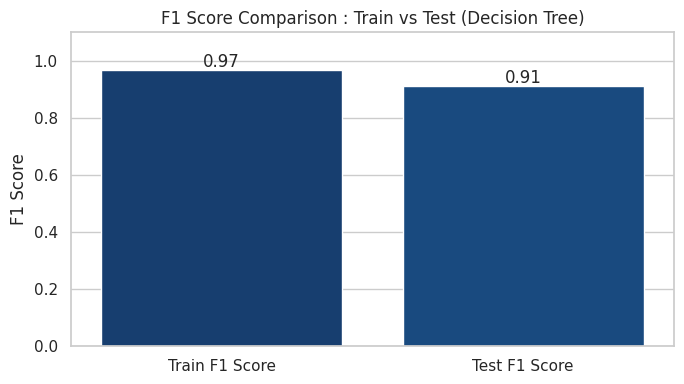

In [202]:

# Calculate F1 Scores
f1_train = f1_score(y_train, y_pred_train)
f1_test = f1_score(y_test, y_pred)

# Create a dictionary
f1_scores = {
    'Train F1 Score': f1_train,
    'Test F1 Score': f1_test
}

# Plot
plt.figure(figsize=(7, 4))
sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette= palette)

# Add value labels on bars
for index, value in enumerate(f1_scores.values()):
    plt.text(index, value + 0.01, f"{value:.2f}", ha='center', fontsize=12)

plt.ylim(0, 1.1)
plt.title("F1 Score Comparison : Train vs Test (Decision Tree)")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

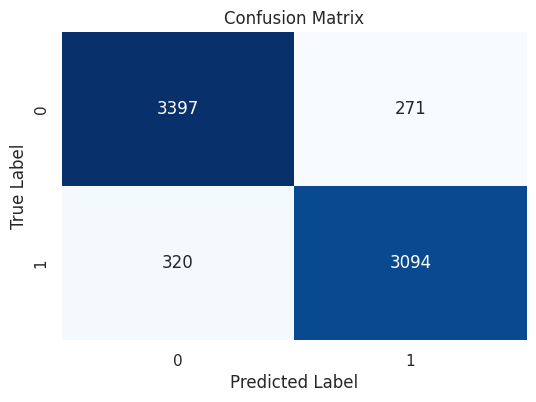

In [203]:
# Example: y_true and y_pred
# Replace these with your actual value

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

2. Cross- Validation & Hyperparameter Tuning

In [204]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Define model
dt = DecisionTreeClassifier(random_state=42)

# Parameter grid (same as GridSearch)
param_dist = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": [None, "sqrt", "log2"]
}

# RandomSearchCV
random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=50,          # number of random combinations to try
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

# Fit model
random_search.fit(x_train, y_train)

# Best model
best_dt_random = random_search.best_estimator_

# Prediction
y_pred_random = best_dt_random.predict(x_test)

# Results
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred_random))

print("\nClassification Report:\n", classification_report(y_test, y_pred_random))



Best Parameters: {'min_samples_split': 20, 'min_samples_leaf': 6, 'max_features': None, 'max_depth': 10, 'criterion': 'entropy'}
Best CV Score: 0.9369402512152327
Test Accuracy: 0.9336345665066366

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94      3668
           1       0.93      0.93      0.93      3414

    accuracy                           0.93      7082
   macro avg       0.93      0.93      0.93      7082
weighted avg       0.93      0.93      0.93      7082



* Predicting on train data to check Overfitting after Tunning

In [205]:
y_pred_best_train = best_dt_random.predict(x_train)

# Evaluation
print("Test Accuracy:", accuracy_score(y_train, y_pred_best_train))

Test Accuracy: 0.9481965625756476


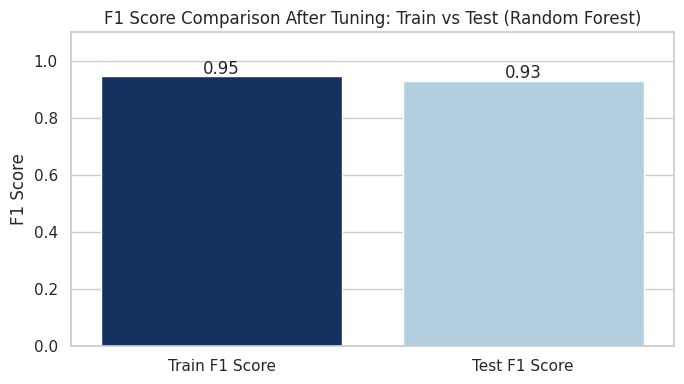

In [206]:
# Calculate F1 Scores
f1_train = f1_score(y_train, y_pred_best_train)
f1_test = f1_score(y_test, y_pred_random)

# Create a dictionary
f1_scores = {
    'Train F1 Score': f1_train,
    'Test F1 Score': f1_test
}

# Plot
plt.figure(figsize=(7, 4))
sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette= ['#08306B','#ACD1E6'])

# Add value labels on bars
for index, value in enumerate(f1_scores.values()):
    plt.text(index, value + 0.01, f"{value:.2f}", ha='center', fontsize=12)

plt.ylim(0, 1.1)
plt.title("F1 Score Comparison After Tuning: Train vs Test (Random Forest)")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

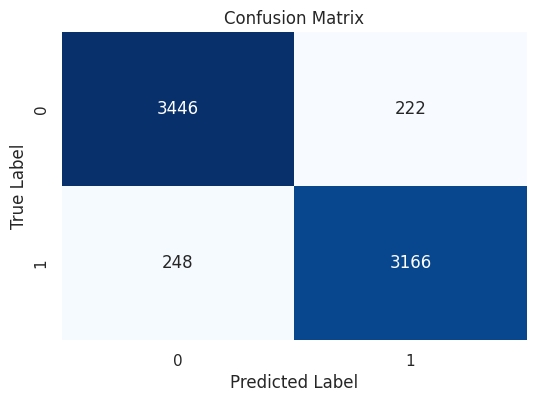

In [207]:
# Create confusion matrix after tuning
cm = confusion_matrix(y_test, y_pred_random)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

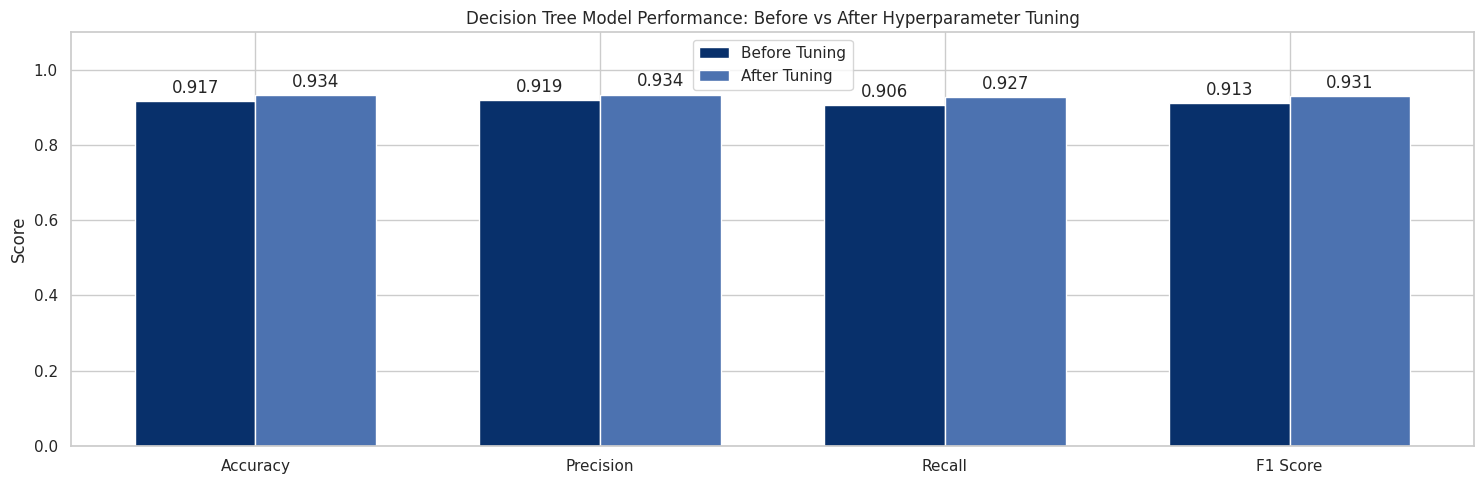

In [208]:
# Default Model Metrics
dt_metrics_default = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred)
}

# Tuned Model Metrics
dt_metrics_tuned = {
    "Accuracy": accuracy_score(y_test, y_pred_random),
    "Precision": precision_score(y_test, y_pred_random),
    "Recall": recall_score(y_test, y_pred_random),
    "F1 Score": f1_score(y_test, y_pred_random)
}

labels = list(dt_metrics_default.keys())
default_values = list(dt_metrics_default.values())
tuned_values = list(dt_metrics_tuned.values())

x = np.arange(len(labels)) # Label locations
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(15, 5))
bars1 = ax.bar(x - width/2, default_values, width, label='Before Tuning',color='#08306B')
bars2 = ax.bar(x + width/2, tuned_values, width, label='After Tuning')

# Add value labels
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

# Labels and titles
ax.set_ylabel('Score')
ax.set_title('Decision Tree Model Performance: Before vs After Hyperparameter Tuning')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0,1.1)
ax.legend()

plt.tight_layout()
plt.show()

* Model Performance is better after Hyperparameter Tuning

1. Which hyperparameter optimization technique have you used and why?
- I used RandomizedSearchCV for hyperparameter optimization because it is computationally efficient and significantly faster, especially when the hyperparameter search space is large.
Additionally, it is more practical for large datasets and reduces the risk of unnecessary computations while still improving model performance.


2. Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.
- Yes, we observed clear improvement after applying cross-validation and hyperparameter tuning. Initially, the **F1 score was 0.91** on the test set and **0.97** on the training set, indicating overfitting. After tuning, the F1 score improved to **0.93** on the test set and **0.94** on the training set, showing that overfitting was significantly reduced and model generalization improved.

3. Buisness Impact -
1. Improved Customer Satisfaction Monitoring
2. Better Targeted Marketing and Loyalty Programs
* By predicting passengers who are likely to recommend the airline, the company can focus marketing campaigns and loyalty offers on high-potential customers.
3. Reduced Customer Churn
* The model can also identify passengers who are less likely to recommend the airline. This allows the airline to take proactive actions such as offering discounts, personalized support
4. Increased Revenue and Brand Reputation
* Accurate recommendation prediction helps improve passenger experience and satisfaction, leading to more positive reviews, stronger brand reputation, higher customer trust, and increased ticket sales

#Model 2 - Random Forest

In [209]:
# modell - 2
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

In [210]:
# Model Evaluation
print("random forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

random forest Accuracy: 0.9271392262072861

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      3668
           1       0.93      0.92      0.92      3414

    accuracy                           0.93      7082
   macro avg       0.93      0.93      0.93      7082
weighted avg       0.93      0.93      0.93      7082


Confusion Matrix:
 [[3417  251]
 [ 265 3149]]


* Predicting on train data to check Overfitting after Tunning

In [211]:
#predict on the model usnig train data
y_pred_rf_train1 = rf_model.predict(x_train)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_train, y_pred_rf_train1))
print(classification_report(y_train, y_pred_rf_train1))


Random Forest Accuracy: 0.9713749697409828
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      8670
           1       0.97      0.97      0.97      7854

    accuracy                           0.97     16524
   macro avg       0.97      0.97      0.97     16524
weighted avg       0.97      0.97      0.97     16524



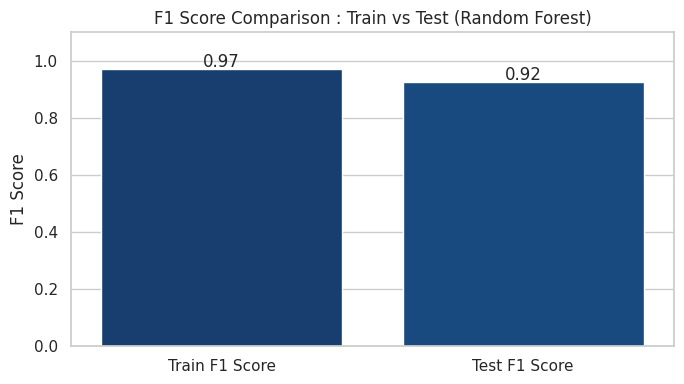

In [212]:
# Calculate F1 Scores
f1_train = f1_score(y_train, y_pred_rf_train1)
f1_test = f1_score(y_test, y_pred_rf)

# Create a dictionary
f1_scores = {
    'Train F1 Score': f1_train,
    'Test F1 Score': f1_test
}

# Plot
plt.figure(figsize=(7, 4))
sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette= palette)

# Add value labels on bars
for index, value in enumerate(f1_scores.values()):
    plt.text(index, value + 0.01, f"{value:.2f}", ha='center', fontsize=12)

plt.ylim(0, 1.1)
plt.title("F1 Score Comparison : Train vs Test (Random Forest)")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

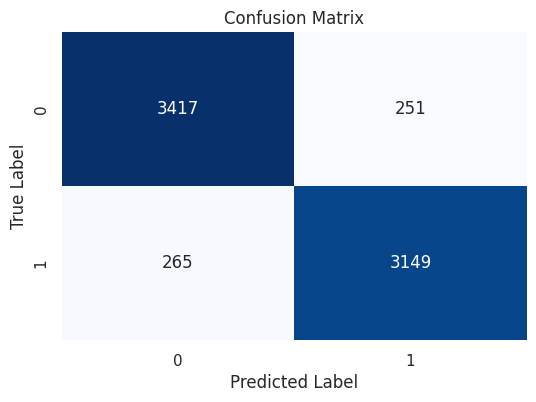

In [213]:
# Example: y_true and y_pred
# Replace these with your actual value

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

2. Cross- Validation & Hyperparameter Tuning

In [214]:
# Define the Random Forest model
rf = RandomForestClassifier(random_state=42)

# Define hyperparameter search space (parameter distribution)
param_dist_rf = {
    "n_estimators": randint(50, 200),          # Number of trees in the forest
    "max_depth": randint(5, 50),           # Maximum depth of each tree
    "min_samples_split": randint(2,20),          # Minimum samples required to split a node
    "min_samples_leaf": randint(1, 6),             # Minimum samples required at a leaf node
    "max_features": ["sqrt", "log2", None],       # Number of features considered for best split
    "bootstrap": [True, False]                    # Whether bootstrap samples are used
}

# Apply RandomizedSearchCV for hyperparameter optimization
random_search_rf = RandomizedSearchCV(
    estimator=rf,                      # Random Forest model
    param_distributions=param_dist_rf, # Parameter combinations
    n_iter=50,                         # Number of random combinations to test
    cv=5,                              # 5-Fold Cross Validation
    scoring="accuracy",                # Evaluation metric
    n_jobs=-1,                         # Use all CPU cores
    random_state=42                    # Reproducibility
)

# Step 4: Train the model using training dataset
random_search_rf.fit(x_train, y_train)

# Step 5: Get the best Random Forest model after tuning
best_rf_model = random_search_rf.best_estimator_

# Step 6: Predict output for test dataset
y_pred_rf_best = best_rf_model.predict(x_test)

# Step 7: Print best hyperparameters and performance results
print("Best Parameters:", random_search_rf.best_params_)
print("Best CV Score:", random_search_rf.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred_rf_best))

# Step 8: Print classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_best))


Best Parameters: {'bootstrap': False, 'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 103}
Best CV Score: 0.9402687431545864
Test Accuracy: 0.9399887037560011

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.94      3668
           1       0.94      0.93      0.94      3414

    accuracy                           0.94      7082
   macro avg       0.94      0.94      0.94      7082
weighted avg       0.94      0.94      0.94      7082



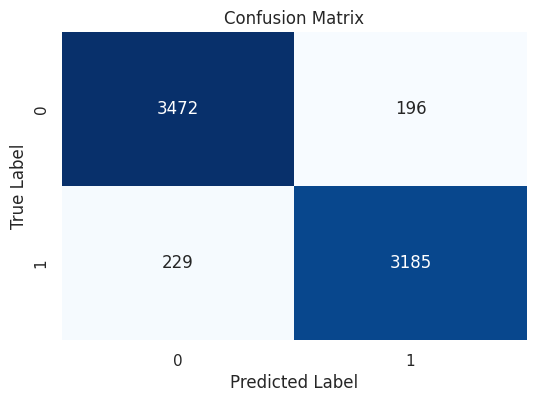

In [215]:
# Create confusion matrix after tuning
cm = confusion_matrix(y_test, y_pred_rf_best)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

* Predicting on train data to check Overfitting after Tunning

In [216]:
y_pred_rf_train = best_rf_model.predict(x_train)

# Evaluation
print("Test Accuracy:", accuracy_score(y_train, y_pred_rf_train))

Test Accuracy: 0.9507383200193658


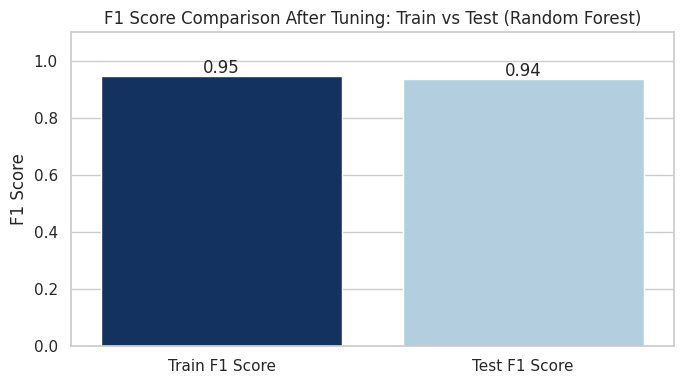

In [217]:
# Calculate F1 Scores
f1_train = f1_score(y_train, y_pred_rf_train)
f1_test = f1_score(y_test, y_pred_rf_best)

# Create a dictionary
f1_scores = {
    'Train F1 Score': f1_train,
    'Test F1 Score': f1_test
}

# Plot
plt.figure(figsize=(7, 4))
sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette= ['#08306B','#ACD1E6'])

# Add value labels on bars
for index, value in enumerate(f1_scores.values()):
    plt.text(index, value + 0.01, f"{value:.2f}", ha='center', fontsize=12)

plt.ylim(0, 1.1)
plt.title("F1 Score Comparison After Tuning: Train vs Test (Random Forest)")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

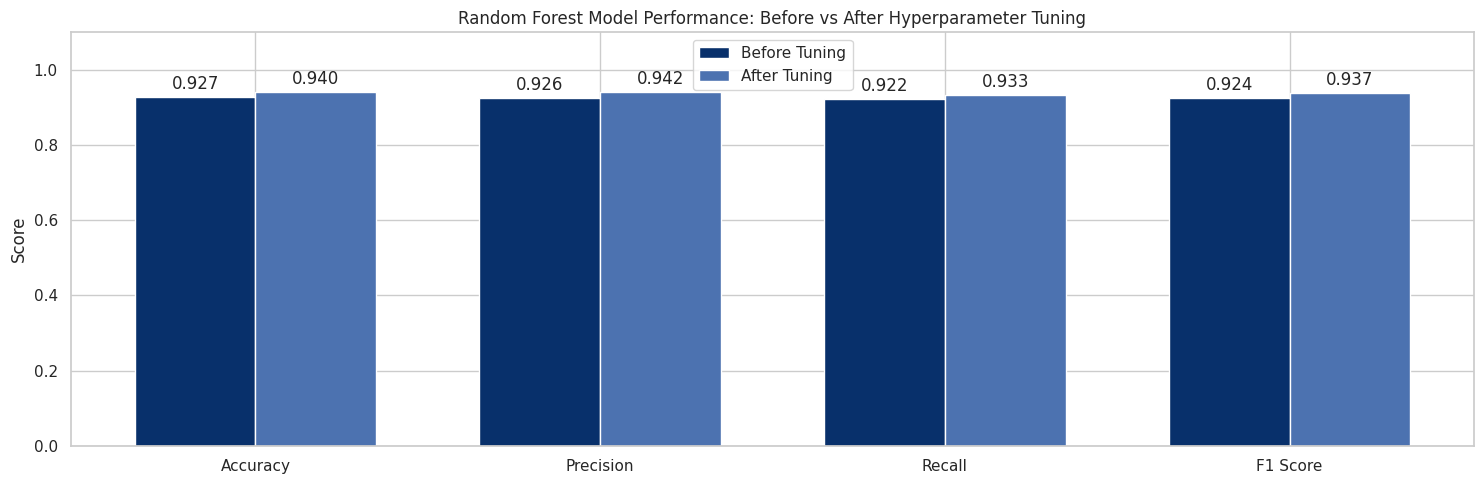

In [218]:
# Default Model Metrics
dt_metrics_default_rf = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf)
}

# Tuned Model Metrics
dt_metrics_tuned_rf = {
    "Accuracy": accuracy_score(y_test, y_pred_rf_best),
    "Precision": precision_score(y_test, y_pred_rf_best),
    "Recall": recall_score(y_test, y_pred_rf_best),
    "F1 Score": f1_score(y_test, y_pred_rf_best)
}

labels = list(dt_metrics_default_rf.keys())
default_values = list(dt_metrics_default_rf.values())
tuned_values = list(dt_metrics_tuned_rf.values())

x = np.arange(len(labels)) # Label locations
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(15, 5))
bars1 = ax.bar(x - width/2, default_values, width, label='Before Tuning',color='#08306B')
bars2 = ax.bar(x + width/2, tuned_values, width, label='After Tuning')

# Add value labels
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

# Labels and titles
ax.set_ylabel('Score')
ax.set_title('Random Forest Model Performance: Before vs After Hyperparameter Tuning')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0,1.1)
ax.legend()

plt.tight_layout()
plt.show()

* Model Performance is better after Hyperparameter Tuning

1. Which hyperparameter optimization technique have you used and why?
* I used RandomizedSearchCV for hyperparameter optimization because it is faster and more efficient than GridSearchCV, especially with limited data and many parameters, as it randomly samples combinations rather than checking every possible one

2. Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.
* The tuned Random Forest model performs better than the default model, with the highest improvement in Precision (+0.016), showing that the model became more accurate in predicting correct passenger recommendations.

#Model 3 -XGboost

In [219]:
# Model - XGBoost
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(x_train, y_train)

y_pred_xgb = xgb_model.predict(x_test)

In [220]:
# Model Evaluation
print("Xgboost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

Xgboost Accuracy: 0.9329285512567072

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94      3668
           1       0.93      0.93      0.93      3414

    accuracy                           0.93      7082
   macro avg       0.93      0.93      0.93      7082
weighted avg       0.93      0.93      0.93      7082


Confusion Matrix:
 [[3443  225]
 [ 250 3164]]


* Predicting on train data to check Overfitting after Tunning

In [221]:
#predict on the model usnig train data
y_pred_xgb_train = rf_model.predict(x_train)

# Evaluation
print("Xgboost Accuracy:", accuracy_score(y_train, y_pred_xgb_train))
print(classification_report(y_train, y_pred_xgb_train))

Xgboost Accuracy: 0.9713749697409828
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      8670
           1       0.97      0.97      0.97      7854

    accuracy                           0.97     16524
   macro avg       0.97      0.97      0.97     16524
weighted avg       0.97      0.97      0.97     16524



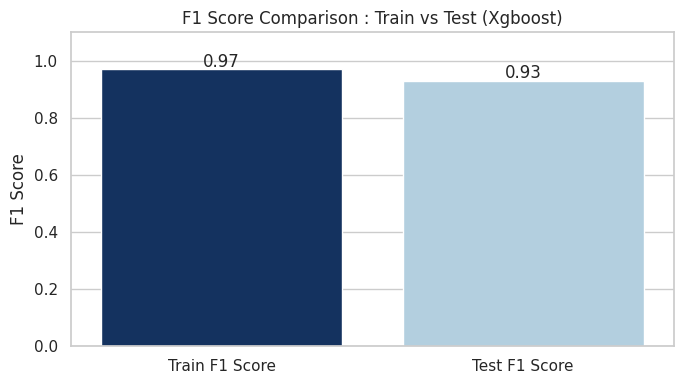

In [222]:
# Calculate F1 Scores
f1_train = f1_score(y_train, y_pred_xgb_train)
f1_test = f1_score(y_test, y_pred_xgb)

# Create a dictionary
f1_scores = {
    'Train F1 Score': f1_train,
    'Test F1 Score': f1_test
}

# Plot
plt.figure(figsize=(7, 4))
sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette= ['#08306B','#ACD1E6'])

# Add value labels on bars
for index, value in enumerate(f1_scores.values()):
    plt.text(index, value + 0.01, f"{value:.2f}", ha='center', fontsize=12)

plt.ylim(0, 1.1)
plt.title("F1 Score Comparison : Train vs Test (Xgboost)")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

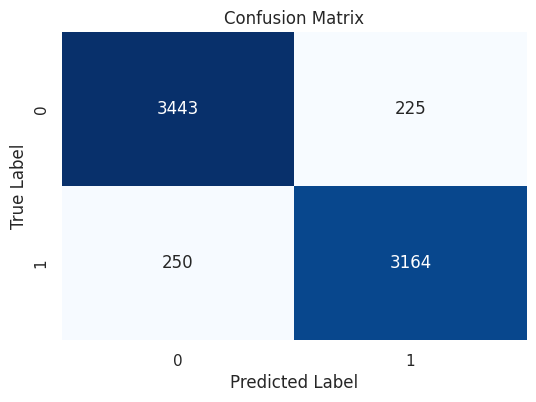

In [223]:
# Create confusion matrix after tuning
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

2. Cross- Validation & Hyperparameter Tuning

In [224]:
# Define XGBoost model
xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

# Important hyperparameters only (useful for accuracy improvement)
param_dist_xgb = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(3, 12),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3)
}

# RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=50,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

# Train model
random_search_xgb.fit(x_train, y_train)

# Best model
best_xgb_model = random_search_xgb.best_estimator_

# Prediction
y_pred_xgb_best = best_xgb_model.predict(x_test)

# Results
print("Best Parameters:", random_search_xgb.best_params_)
print("Best CV Score:", random_search_xgb.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred_xgb_best))

print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb_best))


Best Parameters: {'colsample_bytree': np.float64(0.7566121325024138), 'learning_rate': np.float64(0.06577427051843637), 'max_depth': 5, 'n_estimators': 97, 'subsample': np.float64(0.9539983426714918)}
Best CV Score: 0.9423262867546054
Test Accuracy: 0.9405535159559446

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94      3668
           1       0.94      0.94      0.94      3414

    accuracy                           0.94      7082
   macro avg       0.94      0.94      0.94      7082
weighted avg       0.94      0.94      0.94      7082



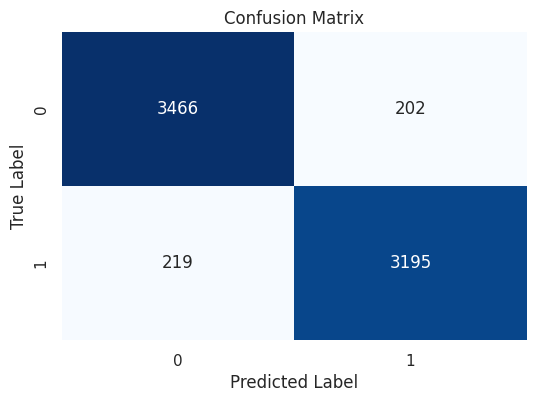

In [225]:
# Create confusion matrix after tuning
cm = confusion_matrix(y_test, y_pred_xgb_best)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

* Predicting on train data to check Overfitting after Tunning

In [226]:
y_pred_xgb_train1 = best_xgb_model.predict(x_train)

# Evaluation
print("Test Accuracy:", accuracy_score(y_train, y_pred_xgb_train1))

Test Accuracy: 0.946562575647543


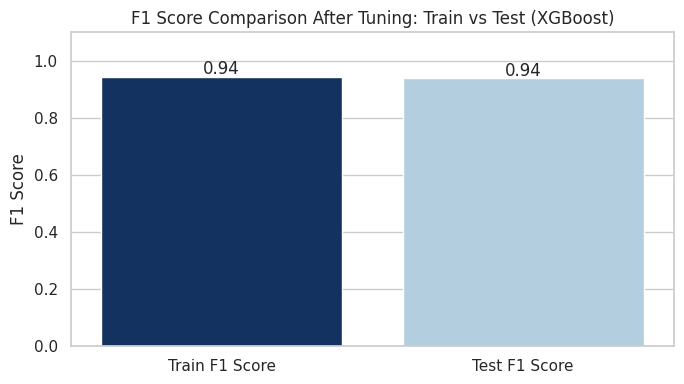

In [227]:
# Calculate F1 Scores
f1_train = f1_score(y_train, y_pred_xgb_train1)
f1_test = f1_score(y_test, y_pred_xgb_best)

# Create a dictionary
f1_scores = {
    'Train F1 Score': f1_train,
    'Test F1 Score': f1_test
}

# Plot
plt.figure(figsize=(7, 4))
sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette= ['#08306B','#ACD1E6'])

# Add value labels on bars
for index, value in enumerate(f1_scores.values()):
    plt.text(index, value + 0.01, f"{value:.2f}", ha='center', fontsize=12)

plt.ylim(0, 1.1)
plt.title("F1 Score Comparison After Tuning: Train vs Test (XGBoost)")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

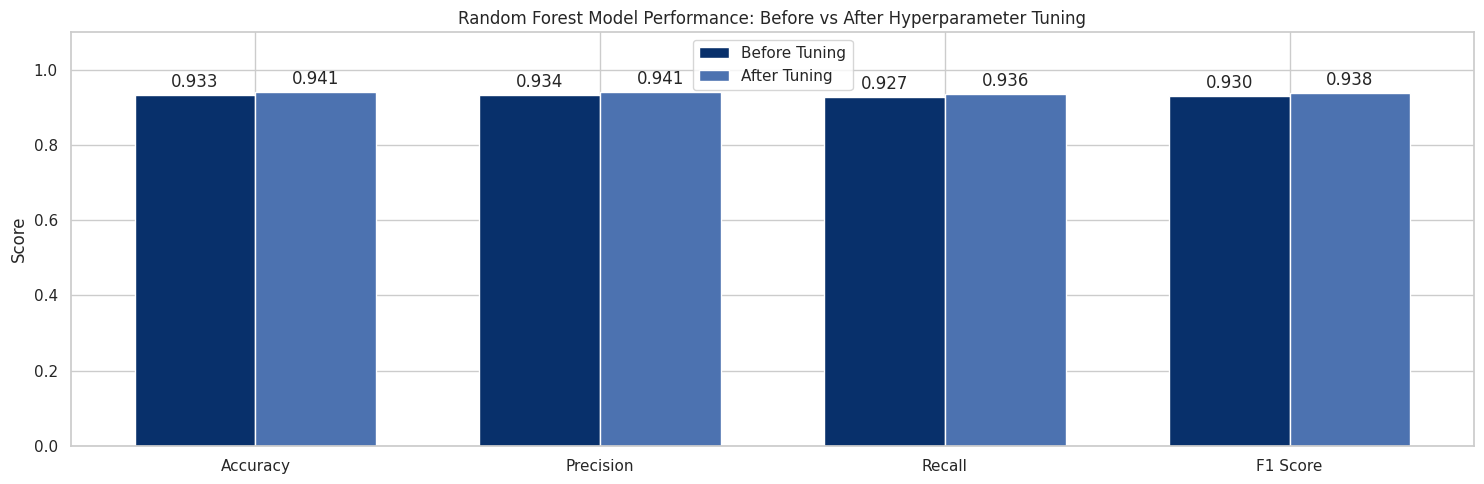

In [228]:
# Default Model Metrics
dt_metrics_default_rf = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb)
}

# Tuned Model Metrics
dt_metrics_tuned_rf = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb_best),
    "Precision": precision_score(y_test, y_pred_xgb_best),
    "Recall": recall_score(y_test, y_pred_xgb_best),
    "F1 Score": f1_score(y_test, y_pred_xgb_best)
}

labels = list(dt_metrics_default_rf.keys())
default_values = list(dt_metrics_default_rf.values())
tuned_values = list(dt_metrics_tuned_rf.values())

x = np.arange(len(labels)) # Label locations
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(15, 5))
bars1 = ax.bar(x - width/2, default_values, width, label='Before Tuning',color='#08306B')
bars2 = ax.bar(x + width/2, tuned_values, width, label='After Tuning')

# Add value labels
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

# Labels and titles
ax.set_ylabel('Score')
ax.set_title('Random Forest Model Performance: Before vs After Hyperparameter Tuning')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0,1.1)
ax.legend()

plt.tight_layout()
plt.show()

* Model Performance is better after Hyperparameter Tuning

1. Which hyperparameter optimization technique have you used and why?
* I used RandomizedSearchCV for hyperparameter optimization because it is faster and more efficient than GridSearchCV, especially with limited data and many parameters, as it randomly samples combinations rather than checking every possible one

2. Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.
* Yes, there is a noticeable improvement after hyperparameter tuning the Random Forest model.
- Accuracy increased from 0.933 to 0.941.
- Precision improved from 0.934 to 0.941, showing fewer incorrect positive predictions.
- Recall increased from 0.927 to 0.936, meaning the model is identifying more true positive cases.
- The F1-score improved from 0.930 to 0.938, indicating a better balance between precision and recall and overall improved model performance.

# 1. Which ML model did you choose from the above created models as your final prediction model and why?

In [229]:
models = {
    "Decision Tree": y_pred_random,
    "Random Forest": y_pred_rf_best,
    "XGBoost": y_pred_xgb_best
}

metrics = {}

for name, y_pred in models.items():
    metrics[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

metrics_df = pd.DataFrame(metrics).T
print(metrics_df)



               Accuracy  Precision    Recall  F1 Score
Decision Tree  0.933635   0.934475  0.927358  0.930903
Random Forest  0.939989   0.942029  0.932923  0.937454
XGBoost        0.940554   0.940536  0.935852  0.938188


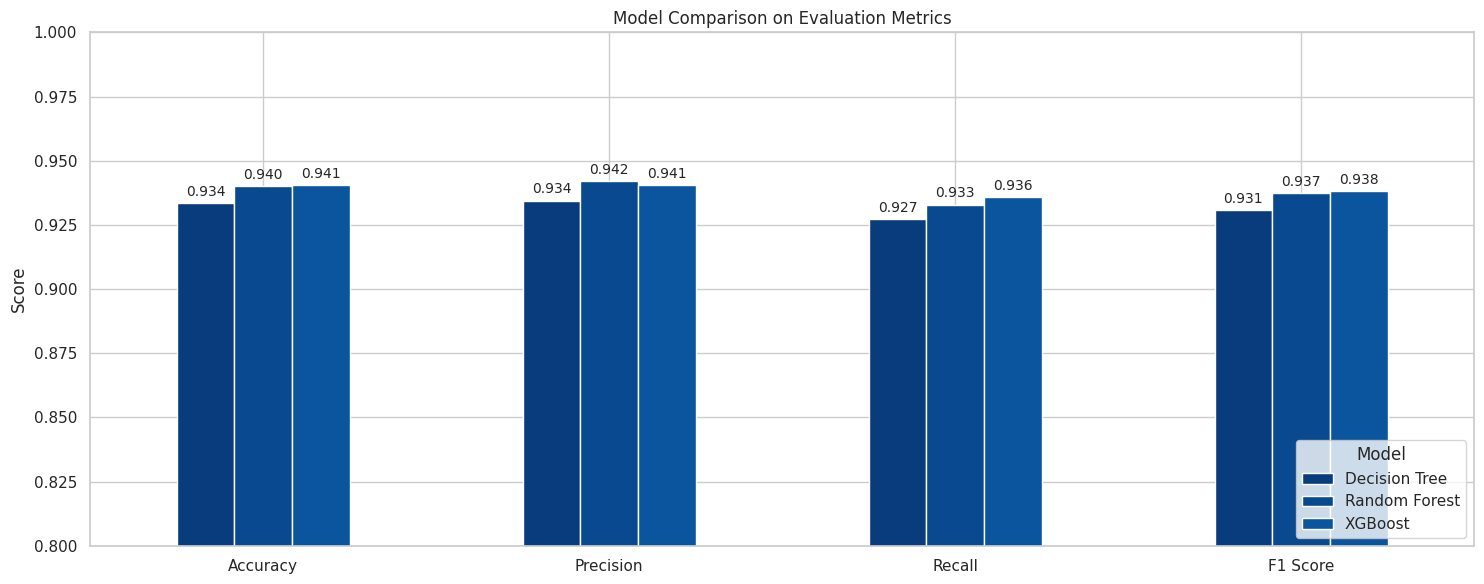

In [230]:
# Set a modern color palette
sns.set_palette(palette)

# Transpose so models become legend, metrics on x-axis
ax = metrics_df.T.plot(kind='bar', figsize=(15, 6))

# Formatting
plt.title("Model Comparison on Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0.8, 1)
plt.xticks(rotation=0)
plt.legend(title="Model", loc='lower right')

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=10, padding=3)

plt.tight_layout()
plt.show()

Final Model Selection: XGBoost

Reason: XGBoost has consistently outperformed both Decision Tree and Random Forest models across all key evaluation metrics:

Accuracy: 0.941
Precision: 0.941
Recall: 0.936
F1 Score: 0.938
These scores indicate that XGBoost provides the best balance between precision and recall, leading to a high F1 Score. This is particularly valuable in classification problems where both false positives and false negatives are important.

Business Impact: Choosing XGBoost ensures:
* More reliable predictions
*  Lower error rates
* Better handling of complex patterns in data, thanks to its boosting framework

# 2. Explain the model which you have used and the feature importance using any model explainability tool?
 - I used XGBoost (Extreme Gradient Boosting) as my final model because it is a powerful ensemble learning algorithm that combines multiple weak decision trees to create a strong predictive model. I selected XGBoost because it provides high accuracy, better generalization, and handles complex patterns in data efficiently. Compared to Decision Tree and Random Forest, XGBoost performed better in my project by giving higher Accuracy and F1-score, which shows that it predicts passenger recommendations more correctly and maintains a good balance between precision and recall.

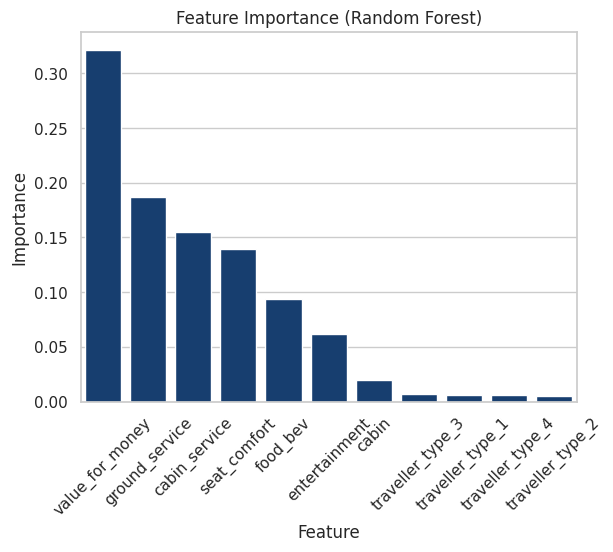

In [231]:

X1 = df1.drop(['recommended'],axis=1)
y1 = df1['recommended']


model = RandomForestClassifier()
model.fit(X1, y1)

importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X1.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

sns.barplot(x='Feature', y='Importance', data=feature_importance_df)
plt.title('Feature Importance (Random Forest)')
plt.xticks(rotation=45)
plt.show()

For model explainability, I used Random Forest feature importance (feature_importances_) as an explainability technique to identify the most influential features affecting the recommendation prediction.
The results were visualized using a bar plot, which effectively highlights the relative importance of features.

In Random Forest, feature importance is calculated based on how much each feature reduces impurity (Gini Index/Entropy) when it is used to split nodes in decision trees. The importance scores are averaged across all trees, and higher values indicate that the feature contributes more to the final prediction.

# Conclusion

This study analyzed a dataset of 131,895 airline reviews (2006–2019) across 17 features. After thorough data cleaning and preprocessing—including fixing date formats, standardizing ratings, and handling missing values—we conducted exploratory data analysis (EDA)

From the overall data analysis, it is observed that Economy Class is the most preferred cabin type, with around 72% passengers choosing Economy, showing that most customers are budget travelers. Also, around 36% passengers are solo travelers, which indicates that individual travel is more common compared to family or group travel.

From rating-based visualizations, it is clearly seen that passengers who recommended the airline gave higher overall ratings in all cabin categories. Business Class and First Class passengers generally provided higher satisfaction ratings compared to Economy Class, meaning premium cabin travelers experience better service quality.

# Feature Importance & Business Impact

Tree-based models revealed that "Value for Money", "Ground Service", and "Cabin Service" were the most influential features. These insights can guide airlines to focus on enhancing service quality to improve customer satisfaction and increase positive recommendations.

This classifier offers practical value in predicting passenger referrals and can support data-driven improvements in airline services.

# Model Performance

I trained three models using a 70/30 split:
XGBoost was the top performer, closely followed by Random Forest.

# I have successfully completed my Machine Learning Capstone Project !!

In [232]:
#import pickle
# save model as pickle file
#pickle.dump(best_xgb_model, open('airline_recommendation_model.pkl', 'wb'))

In [233]:
#from google.colab import files
#files.download('airline_recommendation_model.pkl')